# **Preprocessing**

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# ============================================================
# CELL 1 — Install all required libraries
# ============================================================
!pip install pandas matplotlib seaborn bert-score scikit-learn rouge-score nltk -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.3 MB/s eta 0:00:00


In [8]:
# ============================================================
# CELL 2 — All imports
# ============================================================
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from bert_score import score as bert_score
from rouge_score import rouge_scorer
import nltk

nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.translate.meteor_score import meteor_score as meteor

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 11})

COLORS = {
    "LLaMA":        "#C0504D",
    "Qwen":         "#4F81BD",
    "correct":      "#70AD47",
    "partial":      "#FFC000",
    "hallucinated": "#FF4444",
}

print("All imports successful.")

All imports successful.


In [42]:
# ============================================================
# CELL 3 — Load both JSON files
# ============================================================
# Q vs L
# LLAMA_PATH = "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/DATASETS/llama/llama_3_2_1b_with_labels.json"
# QWEN_PATH  = "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/DATASETS/qwen/qwen_updated_baseline_8thm.json"

# IQ vs IL
# LLAMA_PATH = "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/DATASETS/llama/llama_3_2_1b_finetune_labeled.json"
# QWEN_PATH  = "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/DATASETS/qwen/FT_Validated_qwen.json"

# # Q vs LQ

# LLAMA_PATH = "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/DATASETS/qwen/FT_Validated_qwen.json"
# QWEN_PATH  = "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/DATASETS/qwen/qwen_updated_baseline_8thm.json"

# # L vs IL

QWEN_PATH = "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/DATASETS/llama/llama_3_2_1b_finetune_labeled.json"
LLAMA_PATH  = "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/DATASETS/llama/llama_3_2_1b_with_labels.json"

with open(LLAMA_PATH) as f:
    llama = json.load(f)

with open(QWEN_PATH) as f:
    qwen = json.load(f)

df_llama = pd.DataFrame(llama)
df_qwen  = pd.DataFrame(qwen)

print("LLaMA rows:", len(df_llama))
print("Qwen rows :", len(df_qwen))


LLaMA rows: 200
Qwen rows : 200


In [43]:
# ============================================================
# CELL 4 — Rename columns and merge into one dataframe
# ============================================================
df_llama = df_llama.rename(columns={
    "type":                "question_type",
    "reference_answer":    "ground_truth",
    "llm_answer":          "llama_answer",
    "hallucination_label": "llama_tag",
})

df_qwen = df_qwen.rename(columns={
    "llm_answer":          "qwen_answer",
    "hallucination_label": "qwen_tag",
})

df = df_llama.merge(
    df_qwen[["id", "qwen_answer", "qwen_tag"]],
    on="id"
)

print("Merged shape:", df.shape)
df.head(3)

Merged shape: (200, 11)


,id,topic,question_type,question,ground_truth,source,llama_answer,llama_tag,notes,qwen_answer,qwen_tag
0,1,greenhouse_gases,factual,What is the most abundant anthropogenic greenh...,Carbon dioxide is the most abundant anthropoge...,IPCC AR6,Carbon dioxide (CO2) is the most abundant anth...,partial,None,Carbon dioxide (CO2) is the most abundant anth...,correct
1,2,greenhouse_gases,factual,What is the atmospheric lifetime of methane?,Methane remains in the atmosphere for approxim...,IPCC AR6,The atmospheric lifetime of methane is approxi...,partial,None,"Methane has a very short atmospheric lifetime,...",hallucinated
2,3,greenhouse_gases,factual,What gas is primarily responsible for stratosp...,Chlorofluorocarbons release chlorine atoms in ...,WMO Ozone Assessment,Ozone (O3) is primarily responsible for strato...,hallucinated,None,Chlorine (Cl2).\n\nExplanation: Chlorine is th...,partial


In [44]:
# ============================================================
# CELL 5 — Normalise hallucination tags
# LLaMA : "correct" / "partial" / "hallucinated"
# Qwen  : "Correct" / "Partially Correct" / "Hallucinated"
# Both mapped to: correct / partial / hallucinated
# ============================================================
def norm_tag(t):
    t = str(t).strip().lower()
    if t == "correct":      return "correct"
    if t == "hallucinated": return "hallucinated"
    if "partial" in t:      return "partial"
    return "unknown"

df["llama_tag"] = df["llama_tag"].apply(norm_tag)
df["qwen_tag"]  = df["qwen_tag"].apply(norm_tag)

print("LLaMA tags:", df["llama_tag"].value_counts().to_dict())
print("Qwen tags :", df["qwen_tag"].value_counts().to_dict())

LLaMA tags: {'partial': 91, 'correct': 74, 'hallucinated': 35}
Qwen tags : {'partial': 96, 'correct': 73, 'hallucinated': 31}


# **FACTUAL EVALUATION**

# **Q vs L**

In [26]:
# ============================================================
# CELL 6 — Factual evaluation: Human label + ROUGE-L + METEOR
# ============================================================
factual = df[df["question_type"] == "factual"].copy()

# ── ROUGE-L ──────────────────────────────────────────────────
rscorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def get_rougeL(ref, pred):
    return rscorer.score(str(ref), str(pred))["rougeL"].fmeasure

factual["llama_rougeL"] = factual.apply(
    lambda r: get_rougeL(r["ground_truth"], r["llama_answer"]), axis=1)
factual["qwen_rougeL"]  = factual.apply(
    lambda r: get_rougeL(r["ground_truth"], r["qwen_answer"]),  axis=1)

# ── METEOR ───────────────────────────────────────────────────
def get_meteor(ref, pred):
    ref_tokens  = nltk.word_tokenize(str(ref).lower())
    pred_tokens = nltk.word_tokenize(str(pred).lower())
    return meteor([ref_tokens], pred_tokens)

factual["llama_meteor"] = factual.apply(
    lambda r: get_meteor(r["ground_truth"], r["llama_answer"]), axis=1)
factual["qwen_meteor"]  = factual.apply(
    lambda r: get_meteor(r["ground_truth"], r["qwen_answer"]),  axis=1)

# ── Human-label correct rate (primary metric) ────────────────
llama_factual_acc = (factual["llama_tag"] == "correct").mean()
qwen_factual_acc  = (factual["qwen_tag"]  == "correct").mean()

print("\n===== FACTUAL EVALUATION =====")
print(f"{'Metric':<42} {'LLaMA':>8} {'Qwen':>8}")
print("-" * 60)
print(f"{'Human-label correct rate  [PRIMARY]':<42} {llama_factual_acc*100:>7.1f}% {qwen_factual_acc*100:>7.1f}%")
print(f"{'ROUGE-L mean':<42} {factual['llama_rougeL'].mean():>8.3f} {factual['qwen_rougeL'].mean():>8.3f}")
print(f"{'METEOR mean':<42} {factual['llama_meteor'].mean():>8.3f} {factual['qwen_meteor'].mean():>8.3f}")



===== FACTUAL EVALUATION =====
Metric                                        LLaMA     Qwen
------------------------------------------------------------
Human-label correct rate  [PRIMARY]           36.0%    32.5%
ROUGE-L mean                                  0.291    0.246
METEOR mean                                   0.360    0.366


# **IQ vs IL**

In [33]:
# ============================================================
# CELL 6 — Factual evaluation: Human label + ROUGE-L + METEOR
# ============================================================
factual = df[df["question_type"] == "factual"].copy()

# ── ROUGE-L ──────────────────────────────────────────────────
rscorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def get_rougeL(ref, pred):
    return rscorer.score(str(ref), str(pred))["rougeL"].fmeasure

factual["llama_rougeL"] = factual.apply(
    lambda r: get_rougeL(r["ground_truth"], r["llama_answer"]), axis=1)
factual["qwen_rougeL"]  = factual.apply(
    lambda r: get_rougeL(r["ground_truth"], r["qwen_answer"]),  axis=1)

# ── METEOR ───────────────────────────────────────────────────
def get_meteor(ref, pred):
    ref_tokens  = nltk.word_tokenize(str(ref).lower())
    pred_tokens = nltk.word_tokenize(str(pred).lower())
    return meteor([ref_tokens], pred_tokens)

factual["llama_meteor"] = factual.apply(
    lambda r: get_meteor(r["ground_truth"], r["llama_answer"]), axis=1)
factual["qwen_meteor"]  = factual.apply(
    lambda r: get_meteor(r["ground_truth"], r["qwen_answer"]),  axis=1)

# ── Human-label correct rate (primary metric) ────────────────
llama_factual_acc = (factual["llama_tag"] == "correct").mean()
qwen_factual_acc  = (factual["qwen_tag"]  == "correct").mean()

print("\n===== FACTUAL EVALUATION =====")
print(f"{'Metric':<42} {'LLaMA':>8} {'Qwen':>8}")
print("-" * 60)
print(f"{'Human-label correct rate  [PRIMARY]':<42} {llama_factual_acc*100:>7.1f}% {qwen_factual_acc*100:>7.1f}%")
print(f"{'ROUGE-L mean':<42} {factual['llama_rougeL'].mean():>8.3f} {factual['qwen_rougeL'].mean():>8.3f}")
print(f"{'METEOR mean':<42} {factual['llama_meteor'].mean():>8.3f} {factual['qwen_meteor'].mean():>8.3f}")



===== FACTUAL EVALUATION =====
Metric                                        LLaMA     Qwen
------------------------------------------------------------
Human-label correct rate  [PRIMARY]           34.2%    37.7%
ROUGE-L mean                                  0.298    0.298
METEOR mean                                   0.284    0.357


# **Q vs LQ**

In [38]:
# ============================================================
# CELL 6 — Factual evaluation: Human label + ROUGE-L + METEOR
# ============================================================
factual = df[df["question_type"] == "factual"].copy()

# ── ROUGE-L ──────────────────────────────────────────────────
rscorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def get_rougeL(ref, pred):
    return rscorer.score(str(ref), str(pred))["rougeL"].fmeasure

factual["llama_rougeL"] = factual.apply(
    lambda r: get_rougeL(r["ground_truth"], r["llama_answer"]), axis=1)
factual["qwen_rougeL"]  = factual.apply(
    lambda r: get_rougeL(r["ground_truth"], r["qwen_answer"]),  axis=1)

# ── METEOR ───────────────────────────────────────────────────
def get_meteor(ref, pred):
    ref_tokens  = nltk.word_tokenize(str(ref).lower())
    pred_tokens = nltk.word_tokenize(str(pred).lower())
    return meteor([ref_tokens], pred_tokens)

factual["llama_meteor"] = factual.apply(
    lambda r: get_meteor(r["ground_truth"], r["llama_answer"]), axis=1)
factual["qwen_meteor"]  = factual.apply(
    lambda r: get_meteor(r["ground_truth"], r["qwen_answer"]),  axis=1)

# ── Human-label correct rate (primary metric) ────────────────
llama_factual_acc = (factual["llama_tag"] == "correct").mean()
qwen_factual_acc  = (factual["qwen_tag"]  == "correct").mean()

print("\n===== FACTUAL EVALUATION =====")
print(f"{'Metric':<42} {'LLaMA':>8} {'Qwen':>8}")
print("-" * 60)
print(f"{'Human-label correct rate  [PRIMARY]':<42} {llama_factual_acc*100:>7.1f}% {qwen_factual_acc*100:>7.1f}%")
print(f"{'ROUGE-L mean':<42} {factual['llama_rougeL'].mean():>8.3f} {factual['qwen_rougeL'].mean():>8.3f}")
print(f"{'METEOR mean':<42} {factual['llama_meteor'].mean():>8.3f} {factual['qwen_meteor'].mean():>8.3f}")



===== FACTUAL EVALUATION =====
Metric                                        LLaMA     Qwen
------------------------------------------------------------
Human-label correct rate  [PRIMARY]           37.7%    32.5%
ROUGE-L mean                                  0.295    0.247
METEOR mean                                   0.351    0.368


# **L vs IL**

In [45]:
# ============================================================
# CELL 6 — Factual evaluation: Human label + ROUGE-L + METEOR
# ============================================================
factual = df[df["question_type"] == "factual"].copy()

# ── ROUGE-L ──────────────────────────────────────────────────
rscorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def get_rougeL(ref, pred):
    return rscorer.score(str(ref), str(pred))["rougeL"].fmeasure

factual["llama_rougeL"] = factual.apply(
    lambda r: get_rougeL(r["ground_truth"], r["llama_answer"]), axis=1)
factual["qwen_rougeL"]  = factual.apply(
    lambda r: get_rougeL(r["ground_truth"], r["qwen_answer"]),  axis=1)

# ── METEOR ───────────────────────────────────────────────────
def get_meteor(ref, pred):
    ref_tokens  = nltk.word_tokenize(str(ref).lower())
    pred_tokens = nltk.word_tokenize(str(pred).lower())
    return meteor([ref_tokens], pred_tokens)

factual["llama_meteor"] = factual.apply(
    lambda r: get_meteor(r["ground_truth"], r["llama_answer"]), axis=1)
factual["qwen_meteor"]  = factual.apply(
    lambda r: get_meteor(r["ground_truth"], r["qwen_answer"]),  axis=1)

# ── Human-label correct rate (primary metric) ────────────────
llama_factual_acc = (factual["llama_tag"] == "correct").mean()
qwen_factual_acc  = (factual["qwen_tag"]  == "correct").mean()

print("\n===== FACTUAL EVALUATION =====")
print(f"{'Metric':<42} {'LLaMA':>8} {'Qwen':>8}")
print("-" * 60)
print(f"{'Human-label correct rate  [PRIMARY]':<42} {llama_factual_acc*100:>7.1f}% {qwen_factual_acc*100:>7.1f}%")
print(f"{'ROUGE-L mean':<42} {factual['llama_rougeL'].mean():>8.3f} {factual['qwen_rougeL'].mean():>8.3f}")
print(f"{'METEOR mean':<42} {factual['llama_meteor'].mean():>8.3f} {factual['qwen_meteor'].mean():>8.3f}")



===== FACTUAL EVALUATION =====
Metric                                        LLaMA     Qwen
------------------------------------------------------------
Human-label correct rate  [PRIMARY]           36.0%    34.2%
ROUGE-L mean                                  0.291    0.298
METEOR mean                                   0.360    0.284


# **Explanatory EVALUATION**

# **Q vs L**

In [27]:
# ============================================================
# CELL 7 — Explanatory evaluation: BERTScore
# Uses roberta-large to compare semantic meaning.
# Ignore the RobertaModel LOAD REPORT warnings — harmless.
# ============================================================
expl   = df[df["question_type"] == "explanatory"].copy()
refs   = expl["ground_truth"].tolist()
lpreds = expl["llama_answer"].tolist()
qpreds = expl["qwen_answer"].tolist()

print("Computing BERTScore for LLaMA...")
_, _, F_llama = bert_score(lpreds, refs, lang="en",
                            model_type="roberta-large", verbose=False)
expl["llama_bertscore"] = F_llama.numpy()

print("Computing BERTScore for Qwen...")
_, _, F_qwen = bert_score(qpreds, refs, lang="en",
                           model_type="roberta-large", verbose=False)
expl["qwen_bertscore"] = F_qwen.numpy()

print("\n===== EXPLANATORY BERTScore (F1) =====")
print(f"{'Metric':<42} {'LLaMA':>8} {'Qwen':>8}")
print("-" * 60)
print(f"{'Mean BERTScore F1':<42} {expl['llama_bertscore'].mean():>8.4f} {expl['qwen_bertscore'].mean():>8.4f}")
print(f"{'Median BERTScore F1':<42} {expl['llama_bertscore'].median():>8.4f} {expl['qwen_bertscore'].median():>8.4f}")

Computing BERTScore for LLaMA...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Computing BERTScore for Qwen...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



===== EXPLANATORY BERTScore (F1) =====
Metric                                        LLaMA     Qwen
------------------------------------------------------------
Mean BERTScore F1                            0.8892   0.8816
Median BERTScore F1                          0.8909   0.8818


# **IQ vs IL**

In [34]:
# ============================================================
# CELL 7 — Explanatory evaluation: BERTScore
# Uses roberta-large to compare semantic meaning.
# Ignore the RobertaModel LOAD REPORT warnings — harmless.
# ============================================================
expl   = df[df["question_type"] == "explanatory"].copy()
refs   = expl["ground_truth"].tolist()
lpreds = expl["llama_answer"].tolist()
qpreds = expl["qwen_answer"].tolist()

print("Computing BERTScore for LLaMA...")
_, _, F_llama = bert_score(lpreds, refs, lang="en",
                            model_type="roberta-large", verbose=False)
expl["llama_bertscore"] = F_llama.numpy()

print("Computing BERTScore for Qwen...")
_, _, F_qwen = bert_score(qpreds, refs, lang="en",
                           model_type="roberta-large", verbose=False)
expl["qwen_bertscore"] = F_qwen.numpy()

print("\n===== EXPLANATORY BERTScore (F1) =====")
print(f"{'Metric':<42} {'LLaMA':>8} {'Qwen':>8}")
print("-" * 60)
print(f"{'Mean BERTScore F1':<42} {expl['llama_bertscore'].mean():>8.4f} {expl['qwen_bertscore'].mean():>8.4f}")
print(f"{'Median BERTScore F1':<42} {expl['llama_bertscore'].median():>8.4f} {expl['qwen_bertscore'].median():>8.4f}")

Computing BERTScore for LLaMA...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Computing BERTScore for Qwen...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



===== EXPLANATORY BERTScore (F1) =====
Metric                                        LLaMA     Qwen
------------------------------------------------------------
Mean BERTScore F1                            0.9029   0.8565
Median BERTScore F1                          0.9019   0.8553


# **Q vs LQ**

In [39]:
# ============================================================
# CELL 7 — Explanatory evaluation: BERTScore
# Uses roberta-large to compare semantic meaning.
# Ignore the RobertaModel LOAD REPORT warnings — harmless.
# ============================================================
expl   = df[df["question_type"] == "explanatory"].copy()
refs   = expl["ground_truth"].tolist()
lpreds = expl["llama_answer"].tolist()
qpreds = expl["qwen_answer"].tolist()

print("Computing BERTScore for LLaMA...")
_, _, F_llama = bert_score(lpreds, refs, lang="en",
                            model_type="roberta-large", verbose=False)
expl["llama_bertscore"] = F_llama.numpy()

print("Computing BERTScore for Qwen...")
_, _, F_qwen = bert_score(qpreds, refs, lang="en",
                           model_type="roberta-large", verbose=False)
expl["qwen_bertscore"] = F_qwen.numpy()

print("\n===== EXPLANATORY BERTScore (F1) =====")
print(f"{'Metric':<42} {'LLaMA':>8} {'Qwen':>8}")
print("-" * 60)
print(f"{'Mean BERTScore F1':<42} {expl['llama_bertscore'].mean():>8.4f} {expl['qwen_bertscore'].mean():>8.4f}")
print(f"{'Median BERTScore F1':<42} {expl['llama_bertscore'].median():>8.4f} {expl['qwen_bertscore'].median():>8.4f}")

Computing BERTScore for LLaMA...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Computing BERTScore for Qwen...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



===== EXPLANATORY BERTScore (F1) =====
Metric                                        LLaMA     Qwen
------------------------------------------------------------
Mean BERTScore F1                            0.8565   0.8816
Median BERTScore F1                          0.8553   0.8818


# **L vs IL**

In [46]:
# ============================================================
# CELL 7 — Explanatory evaluation: BERTScore
# Uses roberta-large to compare semantic meaning.
# Ignore the RobertaModel LOAD REPORT warnings — harmless.
# ============================================================
expl   = df[df["question_type"] == "explanatory"].copy()
refs   = expl["ground_truth"].tolist()
lpreds = expl["llama_answer"].tolist()
qpreds = expl["qwen_answer"].tolist()

print("Computing BERTScore for LLaMA...")
_, _, F_llama = bert_score(lpreds, refs, lang="en",
                            model_type="roberta-large", verbose=False)
expl["llama_bertscore"] = F_llama.numpy()

print("Computing BERTScore for Qwen...")
_, _, F_qwen = bert_score(qpreds, refs, lang="en",
                           model_type="roberta-large", verbose=False)
expl["qwen_bertscore"] = F_qwen.numpy()

print("\n===== EXPLANATORY BERTScore (F1) =====")
print(f"{'Metric':<42} {'LLaMA':>8} {'Qwen':>8}")
print("-" * 60)
print(f"{'Mean BERTScore F1':<42} {expl['llama_bertscore'].mean():>8.4f} {expl['qwen_bertscore'].mean():>8.4f}")
print(f"{'Median BERTScore F1':<42} {expl['llama_bertscore'].median():>8.4f} {expl['qwen_bertscore'].median():>8.4f}")

Computing BERTScore for LLaMA...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Computing BERTScore for Qwen...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



===== EXPLANATORY BERTScore (F1) =====
Metric                                        LLaMA     Qwen
------------------------------------------------------------
Mean BERTScore F1                            0.8892   0.9029
Median BERTScore F1                          0.8909   0.9019


# **Hallucination analysis**

# **Q vs L**

In [28]:
# ============================================================
# CELL 8 — Hallucination analysis
# 1. Overall stats
# 2. By question type
# 3. By topic
# 4. Confidence-correctness alignment
# ============================================================

# ── Helper function ───────────────────────────────────────────
def hallu_stats(tag_series, model_name):
    c = tag_series.value_counts()
    n = len(tag_series)
    return {
        "Model":          model_name,
        "Correct":        c.get("correct", 0),
        "Partial":        c.get("partial", 0),
        "Hallucinated":   c.get("hallucinated", 0),
        "Total":          n,
        "Hallu_Rate_%":   round(c.get("hallucinated", 0) / n * 100, 1),
        "Correct_Rate_%": round(c.get("correct", 0)      / n * 100, 1),
        "Partial_Rate_%": round(c.get("partial", 0)      / n * 100, 1),
    }

# ── 1. Overall ───────────────────────────────────────────────
hallu_overall = pd.DataFrame([
    hallu_stats(df["llama_tag"], "LLaMA"),
    hallu_stats(df["qwen_tag"],  "Qwen"),
])

# ── 2. By question type ──────────────────────────────────────
rows = []
for model, col in [("LLaMA", "llama_tag"), ("Qwen", "qwen_tag")]:
    for qtype in ["factual", "explanatory"]:
        sub = df[df["question_type"] == qtype][col]
        s   = hallu_stats(sub, model)
        s["Type"] = qtype
        rows.append(s)
hallu_by_type = pd.DataFrame(rows)

# ── 3. By topic ───────────────────────────────────────────────
topic_hallu = df.groupby("topic").apply(
    lambda g: pd.Series({
        "Total_Qs":        len(g),
        "LLaMA_Hallu_%":   round((g["llama_tag"] == "hallucinated").mean() * 100, 1),
        "Qwen_Hallu_%":    round((g["qwen_tag"]  == "hallucinated").mean() * 100, 1),
        "LLaMA_Correct_%": round((g["llama_tag"] == "correct").mean()      * 100, 1),
        "Qwen_Correct_%":  round((g["qwen_tag"]  == "correct").mean()      * 100, 1),
    })
).reset_index()

# ── 4. Confidence-correctness alignment ──────────────────────
both_correct = df[(df["llama_tag"] == "correct")      & (df["qwen_tag"] == "correct")]
both_hallu   = df[(df["llama_tag"] == "hallucinated") & (df["qwen_tag"] == "hallucinated")]
llama_better = df[(df["llama_tag"] == "correct")      & (df["qwen_tag"] == "hallucinated")]
qwen_better  = df[(df["qwen_tag"]  == "correct")      & (df["llama_tag"] == "hallucinated")]
disagreement = df[df["llama_tag"]  != df["qwen_tag"]]

# ── Print all results ─────────────────────────────────────────
print("===== HALLUCINATION STATS (ALL) =====")
print(hallu_overall[["Model", "Correct", "Partial", "Hallucinated",
                      "Hallu_Rate_%", "Correct_Rate_%", "Partial_Rate_%"]].to_string(index=False))

print("\n===== BY QUESTION TYPE =====")
print(hallu_by_type[["Model", "Type", "Correct", "Partial",
                      "Hallucinated", "Hallu_Rate_%"]].to_string(index=False))

print("\n===== HALLUCINATION RATE BY TOPIC =====")
print(topic_hallu.to_string(index=False))

print("\n===== CONFIDENCE-CORRECTNESS ALIGNMENT =====")
print(f"Both correct       : {len(both_correct):>3} / {len(df)}  ({len(both_correct)/len(df)*100:.1f}%)  — easy / reliable questions")
print(f"Both hallucinated  : {len(both_hallu):>3} / {len(df)}  ({len(both_hallu)/len(df)*100:.1f}%)  — genuinely hard questions")
print(f"LLaMA only correct : {len(llama_better):>3} / {len(df)}  ({len(llama_better)/len(df)*100:.1f}%)  — LLaMA strength")
print(f"Qwen only correct  : {len(qwen_better):>3} / {len(df)}  ({len(qwen_better)/len(df)*100:.1f}%)  — Qwen strength")
print(f"Any disagreement   : {len(disagreement):>3} / {len(df)}  ({len(disagreement)/len(df)*100:.1f}%)")

print("\n── Questions BOTH models hallucinated (first 3) ──")
print(both_hallu[["question", "ground_truth", "llama_answer", "qwen_answer"]].head(3).to_string())

===== HALLUCINATION STATS (ALL) =====
Model  Correct  Partial  Hallucinated  Hallu_Rate_%  Correct_Rate_%  Partial_Rate_%
LLaMA       74       91            35          17.5            37.0            45.5
 Qwen       70       72            58          29.0            35.0            36.0

===== BY QUESTION TYPE =====
Model        Type  Correct  Partial  Hallucinated  Hallu_Rate_%
LLaMA     factual       41       49            24          21.1
LLaMA explanatory       33       42            11          12.8
 Qwen     factual       37       33            44          38.6
 Qwen explanatory       33       39            14          16.3

===== HALLUCINATION RATE BY TOPIC =====
                 topic  Total_Qs  LLaMA_Hallu_%  Qwen_Hallu_%  LLaMA_Correct_%  Qwen_Correct_%
           aerosols_pm      20.0           25.0          40.0             20.0            25.0
 atmospheric_chemistry      20.0           25.0          40.0             30.0            20.0
     climate_feedbacks      20.0  

/tmp/ipykernel_214/1447602481.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  topic_hallu = df.groupby("topic").apply(


# **IQ vs IL**

In [21]:
# ============================================================
# CELL 8 — Hallucination analysis
# 1. Overall stats
# 2. By question type
# 3. By topic
# 4. Confidence-correctness alignment
# ============================================================

# ── Helper function ───────────────────────────────────────────
def hallu_stats(tag_series, model_name):
    c = tag_series.value_counts()
    n = len(tag_series)
    return {
        "Model":          model_name,
        "Correct":        c.get("correct", 0),
        "Partial":        c.get("partial", 0),
        "Hallucinated":   c.get("hallucinated", 0),
        "Total":          n,
        "Hallu_Rate_%":   round(c.get("hallucinated", 0) / n * 100, 1),
        "Correct_Rate_%": round(c.get("correct", 0)      / n * 100, 1),
        "Partial_Rate_%": round(c.get("partial", 0)      / n * 100, 1),
    }

# ── 1. Overall ───────────────────────────────────────────────
hallu_overall = pd.DataFrame([
    hallu_stats(df["llama_tag"], "LLaMA"),
    hallu_stats(df["qwen_tag"],  "Qwen"),
])

# ── 2. By question type ──────────────────────────────────────
rows = []
for model, col in [("LLaMA", "llama_tag"), ("Qwen", "qwen_tag")]:
    for qtype in ["factual", "explanatory"]:
        sub = df[df["question_type"] == qtype][col]
        s   = hallu_stats(sub, model)
        s["Type"] = qtype
        rows.append(s)
hallu_by_type = pd.DataFrame(rows)

# ── 3. By topic ───────────────────────────────────────────────
topic_hallu = df.groupby("topic").apply(
    lambda g: pd.Series({
        "Total_Qs":        len(g),
        "LLaMA_Hallu_%":   round((g["llama_tag"] == "hallucinated").mean() * 100, 1),
        "Qwen_Hallu_%":    round((g["qwen_tag"]  == "hallucinated").mean() * 100, 1),
        "LLaMA_Correct_%": round((g["llama_tag"] == "correct").mean()      * 100, 1),
        "Qwen_Correct_%":  round((g["qwen_tag"]  == "correct").mean()      * 100, 1),
    })
).reset_index()

# ── 4. Confidence-correctness alignment ──────────────────────
both_correct = df[(df["llama_tag"] == "correct")      & (df["qwen_tag"] == "correct")]
both_hallu   = df[(df["llama_tag"] == "hallucinated") & (df["qwen_tag"] == "hallucinated")]
llama_better = df[(df["llama_tag"] == "correct")      & (df["qwen_tag"] == "hallucinated")]
qwen_better  = df[(df["qwen_tag"]  == "correct")      & (df["llama_tag"] == "hallucinated")]
disagreement = df[df["llama_tag"]  != df["qwen_tag"]]

# ── Print all results ─────────────────────────────────────────
print("===== HALLUCINATION STATS (ALL) =====")
print(hallu_overall[["Model", "Correct", "Partial", "Hallucinated",
                      "Hallu_Rate_%", "Correct_Rate_%", "Partial_Rate_%"]].to_string(index=False))

print("\n===== BY QUESTION TYPE =====")
print(hallu_by_type[["Model", "Type", "Correct", "Partial",
                      "Hallucinated", "Hallu_Rate_%"]].to_string(index=False))

print("\n===== HALLUCINATION RATE BY TOPIC =====")
print(topic_hallu.to_string(index=False))

print("\n===== CONFIDENCE-CORRECTNESS ALIGNMENT =====")
print(f"Both correct       : {len(both_correct):>3} / {len(df)}  ({len(both_correct)/len(df)*100:.1f}%)  — easy / reliable questions")
print(f"Both hallucinated  : {len(both_hallu):>3} / {len(df)}  ({len(both_hallu)/len(df)*100:.1f}%)  — genuinely hard questions")
print(f"LLaMA only correct : {len(llama_better):>3} / {len(df)}  ({len(llama_better)/len(df)*100:.1f}%)  — LLaMA strength")
print(f"Qwen only correct  : {len(qwen_better):>3} / {len(df)}  ({len(qwen_better)/len(df)*100:.1f}%)  — Qwen strength")
print(f"Any disagreement   : {len(disagreement):>3} / {len(df)}  ({len(disagreement)/len(df)*100:.1f}%)")

print("\n── Questions BOTH models hallucinated (first 3) ──")
print(both_hallu[["question", "ground_truth", "llama_answer", "qwen_answer"]].head(3).to_string())

===== HALLUCINATION STATS (ALL) =====
Model  Correct  Partial  Hallucinated  Hallu_Rate_%  Correct_Rate_%  Partial_Rate_%
LLaMA       74       91            35          17.5            37.0            45.5
 Qwen       70       72            58          29.0            35.0            36.0

===== BY QUESTION TYPE =====
Model        Type  Correct  Partial  Hallucinated  Hallu_Rate_%
LLaMA     factual       41       49            24          21.1
LLaMA explanatory       33       42            11          12.8
 Qwen     factual       37       33            44          38.6
 Qwen explanatory       33       39            14          16.3

===== HALLUCINATION RATE BY TOPIC =====
                 topic  Total_Qs  LLaMA_Hallu_%  Qwen_Hallu_%  LLaMA_Correct_%  Qwen_Correct_%
           aerosols_pm      20.0           25.0          40.0             20.0            25.0
 atmospheric_chemistry      20.0           25.0          40.0             30.0            20.0
     climate_feedbacks      20.0  

/tmp/ipykernel_214/1447602481.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  topic_hallu = df.groupby("topic").apply(


# **Q vs LQ**

In [40]:
# ============================================================
# CELL 8 — Hallucination analysis
# 1. Overall stats
# 2. By question type
# 3. By topic
# 4. Confidence-correctness alignment
# ============================================================

# ── Helper function ───────────────────────────────────────────
def hallu_stats(tag_series, model_name):
    c = tag_series.value_counts()
    n = len(tag_series)
    return {
        "Model":          model_name,
        "Correct":        c.get("correct", 0),
        "Partial":        c.get("partial", 0),
        "Hallucinated":   c.get("hallucinated", 0),
        "Total":          n,
        "Hallu_Rate_%":   round(c.get("hallucinated", 0) / n * 100, 1),
        "Correct_Rate_%": round(c.get("correct", 0)      / n * 100, 1),
        "Partial_Rate_%": round(c.get("partial", 0)      / n * 100, 1),
    }

# ── 1. Overall ───────────────────────────────────────────────
hallu_overall = pd.DataFrame([
    hallu_stats(df["llama_tag"], "LLaMA"),
    hallu_stats(df["qwen_tag"],  "Qwen"),
])

# ── 2. By question type ──────────────────────────────────────
rows = []
for model, col in [("LLaMA", "llama_tag"), ("Qwen", "qwen_tag")]:
    for qtype in ["factual", "explanatory"]:
        sub = df[df["question_type"] == qtype][col]
        s   = hallu_stats(sub, model)
        s["Type"] = qtype
        rows.append(s)
hallu_by_type = pd.DataFrame(rows)

# ── 3. By topic ───────────────────────────────────────────────
topic_hallu = df.groupby("topic").apply(
    lambda g: pd.Series({
        "Total_Qs":        len(g),
        "LLaMA_Hallu_%":   round((g["llama_tag"] == "hallucinated").mean() * 100, 1),
        "Qwen_Hallu_%":    round((g["qwen_tag"]  == "hallucinated").mean() * 100, 1),
        "LLaMA_Correct_%": round((g["llama_tag"] == "correct").mean()      * 100, 1),
        "Qwen_Correct_%":  round((g["qwen_tag"]  == "correct").mean()      * 100, 1),
    })
).reset_index()

# ── 4. Confidence-correctness alignment ──────────────────────
both_correct = df[(df["llama_tag"] == "correct")      & (df["qwen_tag"] == "correct")]
both_hallu   = df[(df["llama_tag"] == "hallucinated") & (df["qwen_tag"] == "hallucinated")]
llama_better = df[(df["llama_tag"] == "correct")      & (df["qwen_tag"] == "hallucinated")]
qwen_better  = df[(df["qwen_tag"]  == "correct")      & (df["llama_tag"] == "hallucinated")]
disagreement = df[df["llama_tag"]  != df["qwen_tag"]]

# ── Print all results ─────────────────────────────────────────
print("===== HALLUCINATION STATS (ALL) =====")
print(hallu_overall[["Model", "Correct", "Partial", "Hallucinated",
                      "Hallu_Rate_%", "Correct_Rate_%", "Partial_Rate_%"]].to_string(index=False))

print("\n===== BY QUESTION TYPE =====")
print(hallu_by_type[["Model", "Type", "Correct", "Partial",
                      "Hallucinated", "Hallu_Rate_%"]].to_string(index=False))

print("\n===== HALLUCINATION RATE BY TOPIC =====")
print(topic_hallu.to_string(index=False))

print("\n===== CONFIDENCE-CORRECTNESS ALIGNMENT =====")
print(f"Both correct       : {len(both_correct):>3} / {len(df)}  ({len(both_correct)/len(df)*100:.1f}%)  — easy / reliable questions")
print(f"Both hallucinated  : {len(both_hallu):>3} / {len(df)}  ({len(both_hallu)/len(df)*100:.1f}%)  — genuinely hard questions")
print(f"LLaMA only correct : {len(llama_better):>3} / {len(df)}  ({len(llama_better)/len(df)*100:.1f}%)  — LLaMA strength")
print(f"Qwen only correct  : {len(qwen_better):>3} / {len(df)}  ({len(qwen_better)/len(df)*100:.1f}%)  — Qwen strength")
print(f"Any disagreement   : {len(disagreement):>3} / {len(df)}  ({len(disagreement)/len(df)*100:.1f}%)")

print("\n── Questions BOTH models hallucinated (first 3) ──")
print(both_hallu[["question", "ground_truth", "llama_answer", "qwen_answer"]].head(3).to_string())

===== HALLUCINATION STATS (ALL) =====
Model  Correct  Partial  Hallucinated  Hallu_Rate_%  Correct_Rate_%  Partial_Rate_%
LLaMA       87       68            45          22.5            43.5            34.0
 Qwen       70       72            58          29.0            35.0            36.0

===== BY QUESTION TYPE =====
Model        Type  Correct  Partial  Hallucinated  Hallu_Rate_%
LLaMA     factual       43       36            35          30.7
LLaMA explanatory       44       32            10          11.6
 Qwen     factual       37       33            44          38.6
 Qwen explanatory       33       39            14          16.3

===== HALLUCINATION RATE BY TOPIC =====
                 topic  Total_Qs  LLaMA_Hallu_%  Qwen_Hallu_%  LLaMA_Correct_%  Qwen_Correct_%
           aerosols_pm      20.0           30.0          40.0             30.0            25.0
 atmospheric_chemistry      20.0           25.0          40.0             35.0            20.0
     climate_feedbacks      20.0  

/tmp/ipykernel_214/1447602481.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  topic_hallu = df.groupby("topic").apply(


# **L vs IL**

In [47]:
# ============================================================
# CELL 8 — Hallucination analysis
# 1. Overall stats
# 2. By question type
# 3. By topic
# 4. Confidence-correctness alignment
# ============================================================

# ── Helper function ───────────────────────────────────────────
def hallu_stats(tag_series, model_name):
    c = tag_series.value_counts()
    n = len(tag_series)
    return {
        "Model":          model_name,
        "Correct":        c.get("correct", 0),
        "Partial":        c.get("partial", 0),
        "Hallucinated":   c.get("hallucinated", 0),
        "Total":          n,
        "Hallu_Rate_%":   round(c.get("hallucinated", 0) / n * 100, 1),
        "Correct_Rate_%": round(c.get("correct", 0)      / n * 100, 1),
        "Partial_Rate_%": round(c.get("partial", 0)      / n * 100, 1),
    }

# ── 1. Overall ───────────────────────────────────────────────
hallu_overall = pd.DataFrame([
    hallu_stats(df["llama_tag"], "LLaMA"),
    hallu_stats(df["qwen_tag"],  "Qwen"),
])

# ── 2. By question type ──────────────────────────────────────
rows = []
for model, col in [("LLaMA", "llama_tag"), ("Qwen", "qwen_tag")]:
    for qtype in ["factual", "explanatory"]:
        sub = df[df["question_type"] == qtype][col]
        s   = hallu_stats(sub, model)
        s["Type"] = qtype
        rows.append(s)
hallu_by_type = pd.DataFrame(rows)

# ── 3. By topic ───────────────────────────────────────────────
topic_hallu = df.groupby("topic").apply(
    lambda g: pd.Series({
        "Total_Qs":        len(g),
        "LLaMA_Hallu_%":   round((g["llama_tag"] == "hallucinated").mean() * 100, 1),
        "Qwen_Hallu_%":    round((g["qwen_tag"]  == "hallucinated").mean() * 100, 1),
        "LLaMA_Correct_%": round((g["llama_tag"] == "correct").mean()      * 100, 1),
        "Qwen_Correct_%":  round((g["qwen_tag"]  == "correct").mean()      * 100, 1),
    })
).reset_index()

# ── 4. Confidence-correctness alignment ──────────────────────
both_correct = df[(df["llama_tag"] == "correct")      & (df["qwen_tag"] == "correct")]
both_hallu   = df[(df["llama_tag"] == "hallucinated") & (df["qwen_tag"] == "hallucinated")]
llama_better = df[(df["llama_tag"] == "correct")      & (df["qwen_tag"] == "hallucinated")]
qwen_better  = df[(df["qwen_tag"]  == "correct")      & (df["llama_tag"] == "hallucinated")]
disagreement = df[df["llama_tag"]  != df["qwen_tag"]]

# ── Print all results ─────────────────────────────────────────
print("===== HALLUCINATION STATS (ALL) =====")
print(hallu_overall[["Model", "Correct", "Partial", "Hallucinated",
                      "Hallu_Rate_%", "Correct_Rate_%", "Partial_Rate_%"]].to_string(index=False))

print("\n===== BY QUESTION TYPE =====")
print(hallu_by_type[["Model", "Type", "Correct", "Partial",
                      "Hallucinated", "Hallu_Rate_%"]].to_string(index=False))

print("\n===== HALLUCINATION RATE BY TOPIC =====")
print(topic_hallu.to_string(index=False))

print("\n===== CONFIDENCE-CORRECTNESS ALIGNMENT =====")
print(f"Both correct       : {len(both_correct):>3} / {len(df)}  ({len(both_correct)/len(df)*100:.1f}%)  — easy / reliable questions")
print(f"Both hallucinated  : {len(both_hallu):>3} / {len(df)}  ({len(both_hallu)/len(df)*100:.1f}%)  — genuinely hard questions")
print(f"LLaMA only correct : {len(llama_better):>3} / {len(df)}  ({len(llama_better)/len(df)*100:.1f}%)  — LLaMA strength")
print(f"Qwen only correct  : {len(qwen_better):>3} / {len(df)}  ({len(qwen_better)/len(df)*100:.1f}%)  — Qwen strength")
print(f"Any disagreement   : {len(disagreement):>3} / {len(df)}  ({len(disagreement)/len(df)*100:.1f}%)")

print("\n── Questions BOTH models hallucinated (first 3) ──")
print(both_hallu[["question", "ground_truth", "llama_answer", "qwen_answer"]].head(3).to_string())

===== HALLUCINATION STATS (ALL) =====
Model  Correct  Partial  Hallucinated  Hallu_Rate_%  Correct_Rate_%  Partial_Rate_%
LLaMA       74       91            35          17.5            37.0            45.5
 Qwen       73       96            31          15.5            36.5            48.0

===== BY QUESTION TYPE =====
Model        Type  Correct  Partial  Hallucinated  Hallu_Rate_%
LLaMA     factual       41       49            24          21.1
LLaMA explanatory       33       42            11          12.8
 Qwen     factual       39       53            22          19.3
 Qwen explanatory       34       43             9          10.5

===== HALLUCINATION RATE BY TOPIC =====
                 topic  Total_Qs  LLaMA_Hallu_%  Qwen_Hallu_%  LLaMA_Correct_%  Qwen_Correct_%
           aerosols_pm      20.0           25.0          30.0             20.0            20.0
 atmospheric_chemistry      20.0           25.0          15.0             30.0            25.0
     climate_feedbacks      20.0  

/tmp/ipykernel_214/1447602481.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  topic_hallu = df.groupby("topic").apply(


# **visualisations**

# **Q vs L**

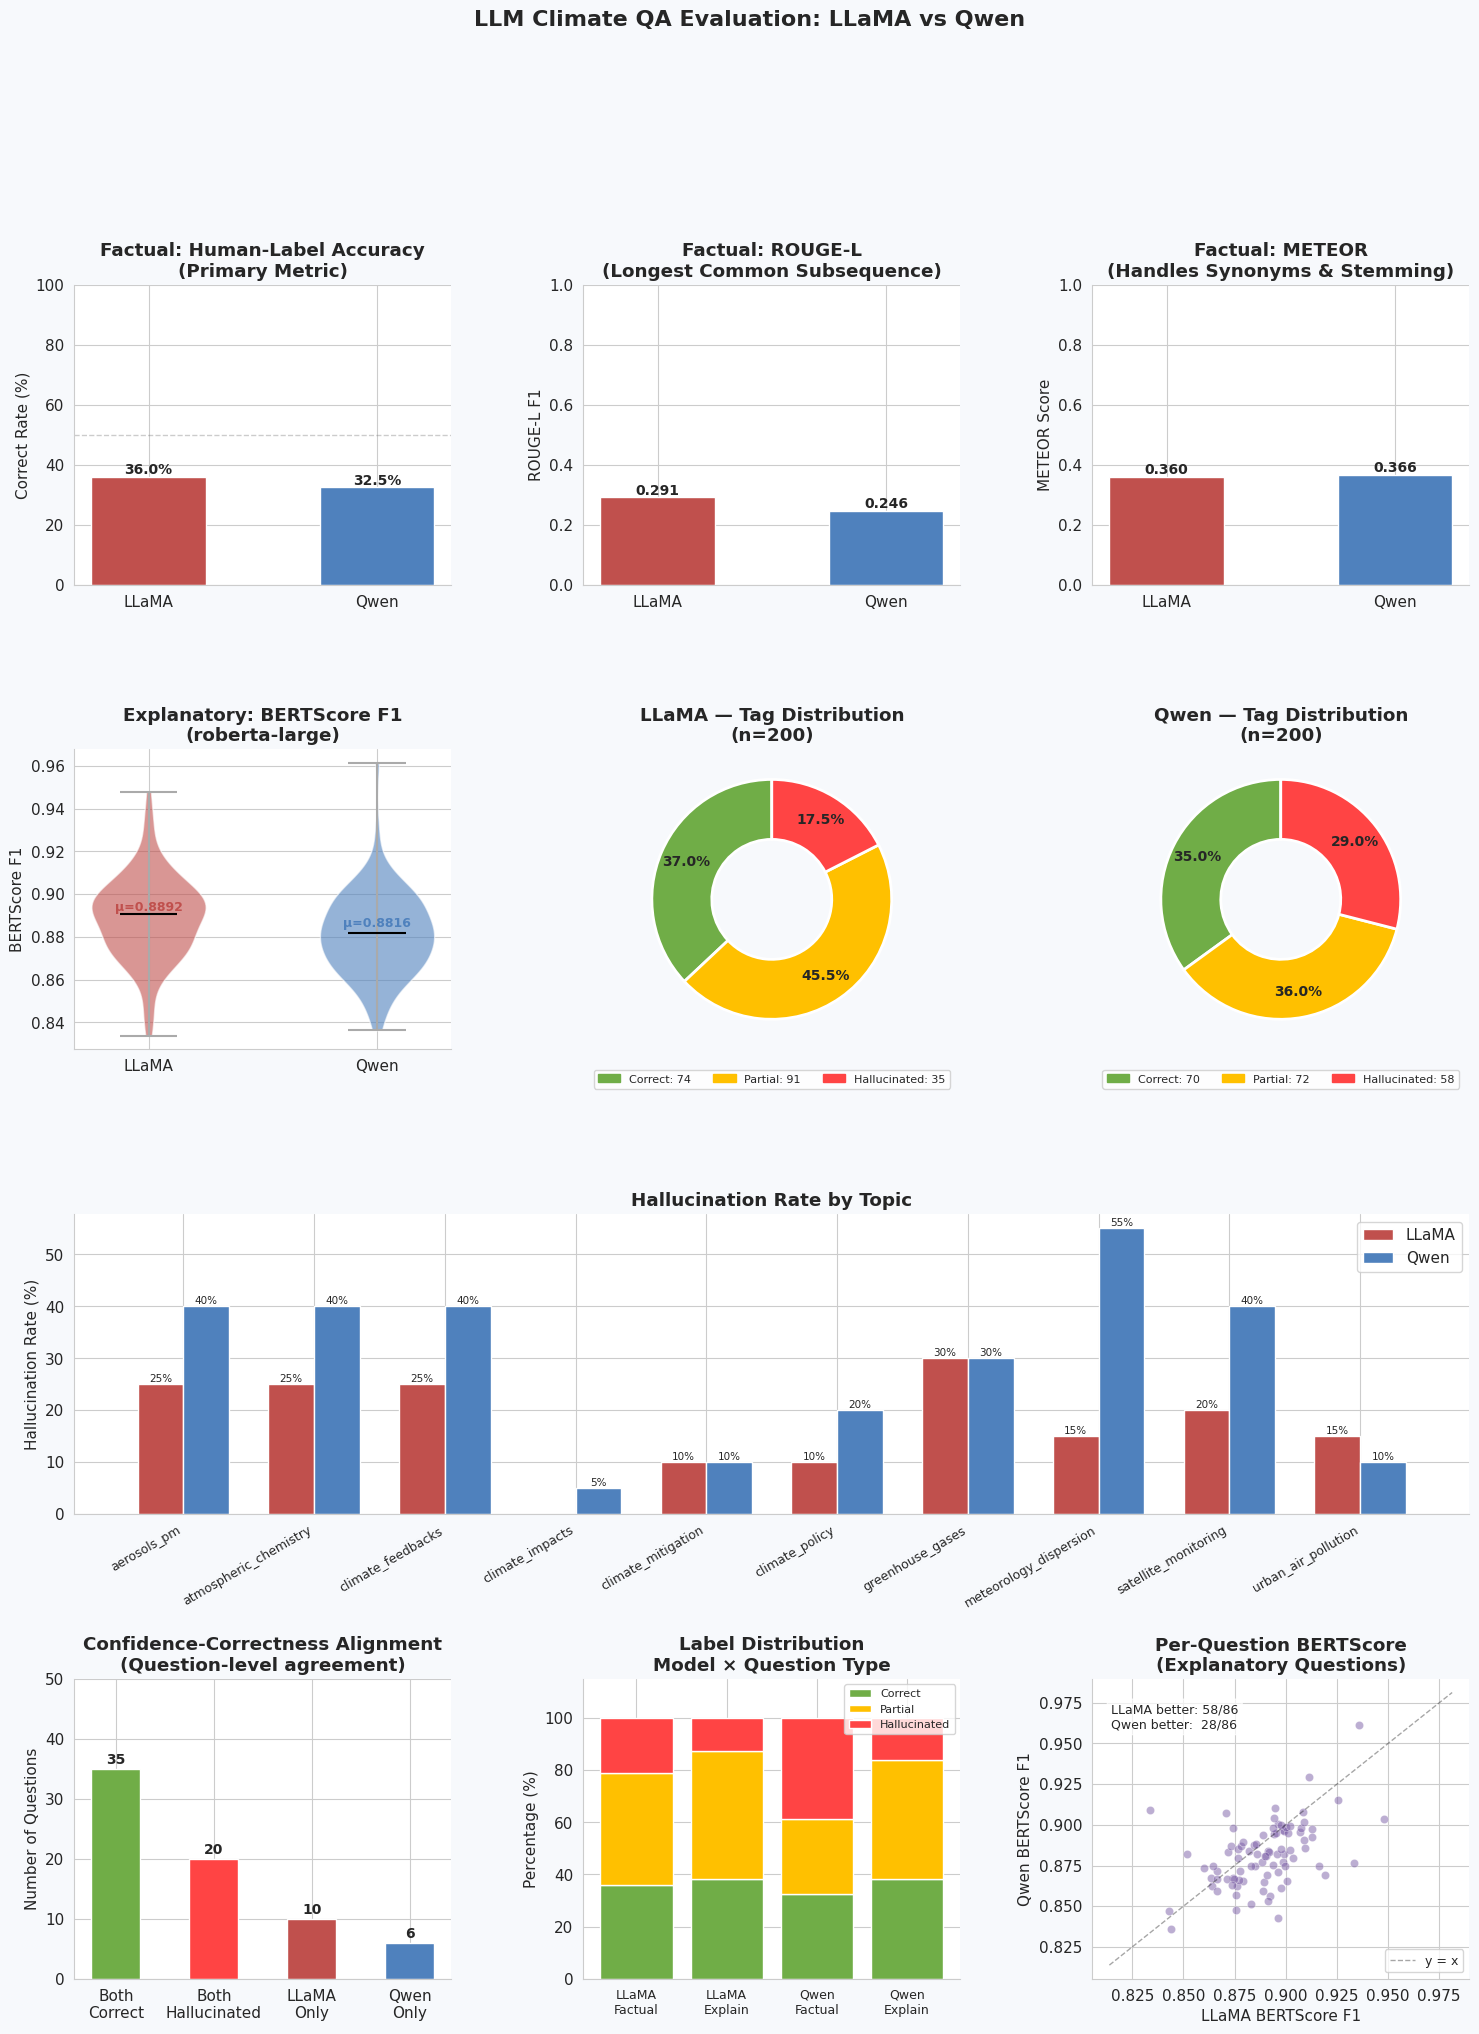

Plot saved to /content/climate_qa_evaluation.png


In [29]:
# ============================================================
# CELL 9 — All visualisations
# 4 rows × 3 columns = 10 plots:
#   Row 1 : Human accuracy | ROUGE-L       | METEOR
#   Row 2 : BERTScore      | LLaMA donut   | Qwen donut
#   Row 3 : Hallucination by topic (full width)
#   Row 4 : Alignment bar  | Stacked dist  | BERTScore scatter
# ============================================================
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 22))
fig.suptitle("LLM Climate QA Evaluation: LLaMA vs Qwen",
             fontsize=16, fontweight="bold", y=1.005)
fig.patch.set_facecolor("#F7F9FC")

gs = GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.35)

def bar_labels(ax, bars, fmt=".1f", suffix=""):
    ylim = ax.get_ylim()[1]
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + ylim * 0.01,
                f"{h:{fmt}}{suffix}", ha="center", fontsize=10, fontweight="bold")

# ── R1C1: Human-label factual accuracy ───────────────────────
ax = fig.add_subplot(gs[0, 0])
vals = [llama_factual_acc * 100, qwen_factual_acc * 100]
bars = ax.bar(["LLaMA", "Qwen"], vals,
              color=[COLORS["LLaMA"], COLORS["Qwen"]], edgecolor="white", width=0.5)
ax.set_ylim(0, 100)
bar_labels(ax, bars, suffix="%")
ax.axhline(50, color="gray", ls="--", alpha=0.4, lw=1)
ax.set_title("Factual: Human-Label Accuracy\n(Primary Metric)", fontweight="bold")
ax.set_ylabel("Correct Rate (%)")
ax.spines[["top", "right"]].set_visible(False)

# ── R1C2: ROUGE-L ─────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
vals = [factual["llama_rougeL"].mean(), factual["qwen_rougeL"].mean()]
bars = ax.bar(["LLaMA", "Qwen"], vals,
              color=[COLORS["LLaMA"], COLORS["Qwen"]], edgecolor="white", width=0.5)
ax.set_ylim(0, 1)
bar_labels(ax, bars, fmt=".3f")
ax.set_title("Factual: ROUGE-L\n(Longest Common Subsequence)", fontweight="bold")
ax.set_ylabel("ROUGE-L F1")
ax.spines[["top", "right"]].set_visible(False)

# ── R1C3: METEOR ──────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
vals = [factual["llama_meteor"].mean(), factual["qwen_meteor"].mean()]
bars = ax.bar(["LLaMA", "Qwen"], vals,
              color=[COLORS["LLaMA"], COLORS["Qwen"]], edgecolor="white", width=0.5)
ax.set_ylim(0, 1)
bar_labels(ax, bars, fmt=".3f")
ax.set_title("Factual: METEOR\n(Handles Synonyms & Stemming)", fontweight="bold")
ax.set_ylabel("METEOR Score")
ax.spines[["top", "right"]].set_visible(False)

# ── R2C1: BERTScore violin ────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
vp = ax.violinplot(
    [expl["llama_bertscore"].values, expl["qwen_bertscore"].values],
    positions=[1, 2], showmedians=True)
for body, color in zip(vp["bodies"], [COLORS["LLaMA"], COLORS["Qwen"]]):
    body.set_facecolor(color)
    body.set_alpha(0.6)
vp["cmedians"].set_color("black")
for part in ("cmins", "cmaxes", "cbars"):
    vp[part].set_color("#aaa")
ax.set_xticks([1, 2])
ax.set_xticklabels(["LLaMA", "Qwen"])
for i, (val, col) in enumerate(zip(
        [expl["llama_bertscore"].mean(), expl["qwen_bertscore"].mean()],
        [COLORS["LLaMA"], COLORS["Qwen"]]), 1):
    ax.text(i, val + 0.003, f"μ={val:.4f}", ha="center",
            fontsize=9, fontweight="bold", color=col)
ax.set_title("Explanatory: BERTScore F1\n(roberta-large)", fontweight="bold")
ax.set_ylabel("BERTScore F1")
ax.spines[["top", "right"]].set_visible(False)

# ── R2C2 & R2C3: Hallucination donut charts ──────────────────
for idx, (model, col) in enumerate([("LLaMA", "llama_tag"), ("Qwen", "qwen_tag")]):
    ax = fig.add_subplot(gs[1, idx + 1])
    counts = df[col].value_counts()
    labels = ["correct", "partial", "hallucinated"]
    sizes  = [counts.get(l, 0) for l in labels]
    colors = [COLORS[l] for l in labels]
    _, _, autotexts = ax.pie(
        sizes, colors=colors, autopct="%1.1f%%",
        startangle=90, pctdistance=0.78,
        wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2))
    for at in autotexts:
        at.set_fontsize(10)
        at.set_fontweight("bold")
    ax.set_title(f"{model} — Tag Distribution\n(n={len(df)})", fontweight="bold")
    ax.legend(
        handles=[mpatches.Patch(color=COLORS[l],
                 label=f"{l.title()}: {counts.get(l, 0)}") for l in labels],
        loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8)

# ── R3: Hallucination by topic (full width) ──────────────────
ax_topic = fig.add_subplot(gs[2, :])
topics = topic_hallu["topic"].tolist()
x = np.arange(len(topics))
w = 0.35
b1 = ax_topic.bar(x - w / 2, topic_hallu["LLaMA_Hallu_%"], w,
                   label="LLaMA", color=COLORS["LLaMA"], edgecolor="white")
b2 = ax_topic.bar(x + w / 2, topic_hallu["Qwen_Hallu_%"],  w,
                   label="Qwen",  color=COLORS["Qwen"],  edgecolor="white")
ax_topic.set_xticks(x)
ax_topic.set_xticklabels(topics, rotation=30, ha="right", fontsize=9)
ax_topic.set_ylabel("Hallucination Rate (%)")
ax_topic.set_title("Hallucination Rate by Topic", fontweight="bold")
ax_topic.legend()
ax_topic.spines[["top", "right"]].set_visible(False)
for b in list(b1) + list(b2):
    h = b.get_height()
    if h > 0:
        ax_topic.text(b.get_x() + b.get_width() / 2, h + 0.5,
                      f"{h:.0f}%", ha="center", fontsize=7.5)

# ── R4C1: Confidence-correctness alignment ────────────────────
ax = fig.add_subplot(gs[3, 0])
categories   = ["Both\nCorrect", "Both\nHallucinated", "LLaMA\nOnly", "Qwen\nOnly"]
counts_align = [len(both_correct), len(both_hallu), len(llama_better), len(qwen_better)]
bar_colors   = [COLORS["correct"], COLORS["hallucinated"], COLORS["LLaMA"], COLORS["Qwen"]]
bars = ax.bar(categories, counts_align, color=bar_colors, edgecolor="white", width=0.5)
ax.set_ylim(0, max(counts_align) + 15)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.8,
            str(int(b.get_height())), ha="center", fontsize=10, fontweight="bold")
ax.set_title("Confidence-Correctness Alignment\n(Question-level agreement)", fontweight="bold")
ax.set_ylabel("Number of Questions")
ax.spines[["top", "right"]].set_visible(False)

# ── R4C2: Stacked label distribution model × type ────────────
ax = fig.add_subplot(gs[3, 1])
combos   = ["LLaMA\nFactual", "LLaMA\nExplain", "Qwen\nFactual", "Qwen\nExplain"]
data_map = {}
for model, col in [("LLaMA", "llama_tag"), ("Qwen", "qwen_tag")]:
    for qtype in ["factual", "explanatory"]:
        sub = df[df["question_type"] == qtype][col].value_counts()
        n   = len(df[df["question_type"] == qtype])
        key = f"{model}\n{'Factual' if qtype == 'factual' else 'Explain'}"
        data_map[key] = {l: sub.get(l, 0) / n * 100
                         for l in ["correct", "partial", "hallucinated"]}
x   = np.arange(4)
bot = np.zeros(4)
for label in ["correct", "partial", "hallucinated"]:
    vals = [data_map[k][label] for k in combos]
    ax.bar(x, vals, bottom=bot, color=COLORS[label],
           label=label.title(), edgecolor="white")
    bot += np.array(vals)
ax.set_xticks(x)
ax.set_xticklabels(combos, fontsize=9)
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 115)
ax.set_title("Label Distribution\nModel × Question Type", fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# ── R4C3: BERTScore scatter per question ─────────────────────
ax = fig.add_subplot(gs[3, 2])
ax.scatter(expl["llama_bertscore"], expl["qwen_bertscore"],
           alpha=0.5, s=35, color="#7B5EA7", edgecolors="white", linewidths=0.4)
lo = min(expl["llama_bertscore"].min(), expl["qwen_bertscore"].min()) - 0.02
hi = max(expl["llama_bertscore"].max(), expl["qwen_bertscore"].max()) + 0.02
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.35, lw=1, label="y = x")
lb = (expl["llama_bertscore"] > expl["qwen_bertscore"]).sum()
qb = (expl["qwen_bertscore"]  > expl["llama_bertscore"]).sum()
ax.text(0.05, 0.92,
        f"LLaMA better: {lb}/{len(expl)}\nQwen better:  {qb}/{len(expl)}",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
ax.set_xlabel("LLaMA BERTScore F1")
ax.set_ylabel("Qwen BERTScore F1")
ax.set_title("Per-Question BERTScore\n(Explanatory Questions)", fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.savefig("/content/climate_qa_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to /content/climate_qa_evaluation.png")

# ***IQ vs IL***

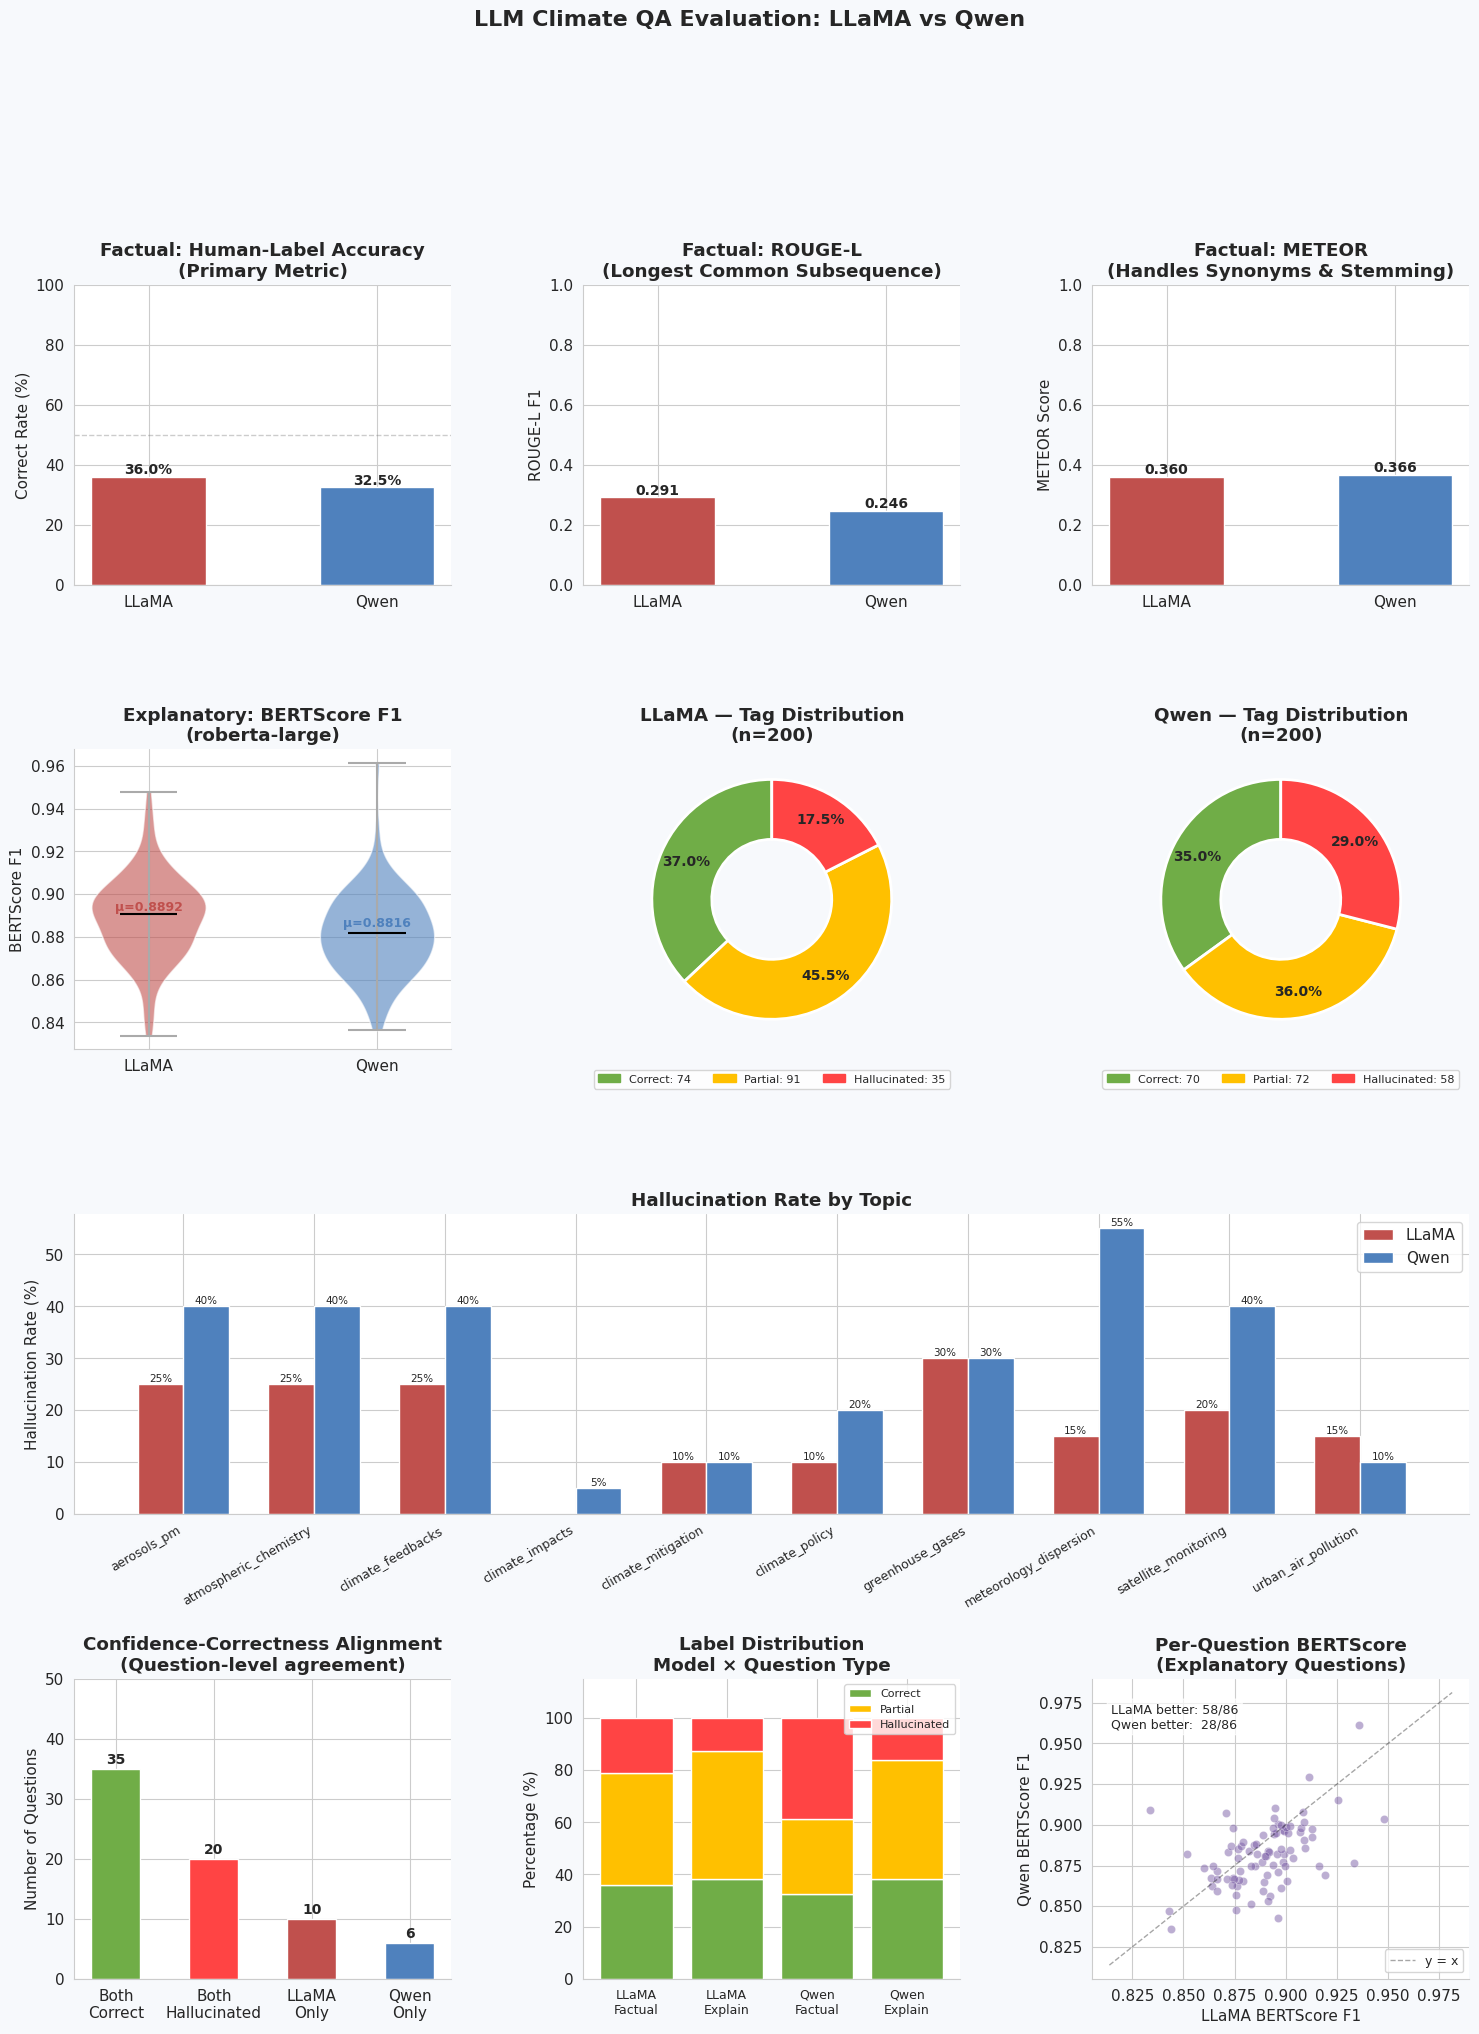

Plot saved to /content/climate_qa_evaluation.png


In [22]:
# ============================================================
# CELL 9 — All visualisations
# 4 rows × 3 columns = 10 plots:
#   Row 1 : Human accuracy | ROUGE-L       | METEOR
#   Row 2 : BERTScore      | LLaMA donut   | Qwen donut
#   Row 3 : Hallucination by topic (full width)
#   Row 4 : Alignment bar  | Stacked dist  | BERTScore scatter
# ============================================================
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 22))
fig.suptitle("LLM Climate QA Evaluation: LLaMA vs Qwen",
             fontsize=16, fontweight="bold", y=1.005)
fig.patch.set_facecolor("#F7F9FC")

gs = GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.35)

def bar_labels(ax, bars, fmt=".1f", suffix=""):
    ylim = ax.get_ylim()[1]
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + ylim * 0.01,
                f"{h:{fmt}}{suffix}", ha="center", fontsize=10, fontweight="bold")

# ── R1C1: Human-label factual accuracy ───────────────────────
ax = fig.add_subplot(gs[0, 0])
vals = [llama_factual_acc * 100, qwen_factual_acc * 100]
bars = ax.bar(["LLaMA", "Qwen"], vals,
              color=[COLORS["LLaMA"], COLORS["Qwen"]], edgecolor="white", width=0.5)
ax.set_ylim(0, 100)
bar_labels(ax, bars, suffix="%")
ax.axhline(50, color="gray", ls="--", alpha=0.4, lw=1)
ax.set_title("Factual: Human-Label Accuracy\n(Primary Metric)", fontweight="bold")
ax.set_ylabel("Correct Rate (%)")
ax.spines[["top", "right"]].set_visible(False)

# ── R1C2: ROUGE-L ─────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
vals = [factual["llama_rougeL"].mean(), factual["qwen_rougeL"].mean()]
bars = ax.bar(["LLaMA", "Qwen"], vals,
              color=[COLORS["LLaMA"], COLORS["Qwen"]], edgecolor="white", width=0.5)
ax.set_ylim(0, 1)
bar_labels(ax, bars, fmt=".3f")
ax.set_title("Factual: ROUGE-L\n(Longest Common Subsequence)", fontweight="bold")
ax.set_ylabel("ROUGE-L F1")
ax.spines[["top", "right"]].set_visible(False)

# ── R1C3: METEOR ──────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
vals = [factual["llama_meteor"].mean(), factual["qwen_meteor"].mean()]
bars = ax.bar(["LLaMA", "Qwen"], vals,
              color=[COLORS["LLaMA"], COLORS["Qwen"]], edgecolor="white", width=0.5)
ax.set_ylim(0, 1)
bar_labels(ax, bars, fmt=".3f")
ax.set_title("Factual: METEOR\n(Handles Synonyms & Stemming)", fontweight="bold")
ax.set_ylabel("METEOR Score")
ax.spines[["top", "right"]].set_visible(False)

# ── R2C1: BERTScore violin ────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
vp = ax.violinplot(
    [expl["llama_bertscore"].values, expl["qwen_bertscore"].values],
    positions=[1, 2], showmedians=True)
for body, color in zip(vp["bodies"], [COLORS["LLaMA"], COLORS["Qwen"]]):
    body.set_facecolor(color)
    body.set_alpha(0.6)
vp["cmedians"].set_color("black")
for part in ("cmins", "cmaxes", "cbars"):
    vp[part].set_color("#aaa")
ax.set_xticks([1, 2])
ax.set_xticklabels(["LLaMA", "Qwen"])
for i, (val, col) in enumerate(zip(
        [expl["llama_bertscore"].mean(), expl["qwen_bertscore"].mean()],
        [COLORS["LLaMA"], COLORS["Qwen"]]), 1):
    ax.text(i, val + 0.003, f"μ={val:.4f}", ha="center",
            fontsize=9, fontweight="bold", color=col)
ax.set_title("Explanatory: BERTScore F1\n(roberta-large)", fontweight="bold")
ax.set_ylabel("BERTScore F1")
ax.spines[["top", "right"]].set_visible(False)

# ── R2C2 & R2C3: Hallucination donut charts ──────────────────
for idx, (model, col) in enumerate([("LLaMA", "llama_tag"), ("Qwen", "qwen_tag")]):
    ax = fig.add_subplot(gs[1, idx + 1])
    counts = df[col].value_counts()
    labels = ["correct", "partial", "hallucinated"]
    sizes  = [counts.get(l, 0) for l in labels]
    colors = [COLORS[l] for l in labels]
    _, _, autotexts = ax.pie(
        sizes, colors=colors, autopct="%1.1f%%",
        startangle=90, pctdistance=0.78,
        wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2))
    for at in autotexts:
        at.set_fontsize(10)
        at.set_fontweight("bold")
    ax.set_title(f"{model} — Tag Distribution\n(n={len(df)})", fontweight="bold")
    ax.legend(
        handles=[mpatches.Patch(color=COLORS[l],
                 label=f"{l.title()}: {counts.get(l, 0)}") for l in labels],
        loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8)

# ── R3: Hallucination by topic (full width) ──────────────────
ax_topic = fig.add_subplot(gs[2, :])
topics = topic_hallu["topic"].tolist()
x = np.arange(len(topics))
w = 0.35
b1 = ax_topic.bar(x - w / 2, topic_hallu["LLaMA_Hallu_%"], w,
                   label="LLaMA", color=COLORS["LLaMA"], edgecolor="white")
b2 = ax_topic.bar(x + w / 2, topic_hallu["Qwen_Hallu_%"],  w,
                   label="Qwen",  color=COLORS["Qwen"],  edgecolor="white")
ax_topic.set_xticks(x)
ax_topic.set_xticklabels(topics, rotation=30, ha="right", fontsize=9)
ax_topic.set_ylabel("Hallucination Rate (%)")
ax_topic.set_title("Hallucination Rate by Topic", fontweight="bold")
ax_topic.legend()
ax_topic.spines[["top", "right"]].set_visible(False)
for b in list(b1) + list(b2):
    h = b.get_height()
    if h > 0:
        ax_topic.text(b.get_x() + b.get_width() / 2, h + 0.5,
                      f"{h:.0f}%", ha="center", fontsize=7.5)

# ── R4C1: Confidence-correctness alignment ────────────────────
ax = fig.add_subplot(gs[3, 0])
categories   = ["Both\nCorrect", "Both\nHallucinated", "LLaMA\nOnly", "Qwen\nOnly"]
counts_align = [len(both_correct), len(both_hallu), len(llama_better), len(qwen_better)]
bar_colors   = [COLORS["correct"], COLORS["hallucinated"], COLORS["LLaMA"], COLORS["Qwen"]]
bars = ax.bar(categories, counts_align, color=bar_colors, edgecolor="white", width=0.5)
ax.set_ylim(0, max(counts_align) + 15)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.8,
            str(int(b.get_height())), ha="center", fontsize=10, fontweight="bold")
ax.set_title("Confidence-Correctness Alignment\n(Question-level agreement)", fontweight="bold")
ax.set_ylabel("Number of Questions")
ax.spines[["top", "right"]].set_visible(False)

# ── R4C2: Stacked label distribution model × type ────────────
ax = fig.add_subplot(gs[3, 1])
combos   = ["LLaMA\nFactual", "LLaMA\nExplain", "Qwen\nFactual", "Qwen\nExplain"]
data_map = {}
for model, col in [("LLaMA", "llama_tag"), ("Qwen", "qwen_tag")]:
    for qtype in ["factual", "explanatory"]:
        sub = df[df["question_type"] == qtype][col].value_counts()
        n   = len(df[df["question_type"] == qtype])
        key = f"{model}\n{'Factual' if qtype == 'factual' else 'Explain'}"
        data_map[key] = {l: sub.get(l, 0) / n * 100
                         for l in ["correct", "partial", "hallucinated"]}
x   = np.arange(4)
bot = np.zeros(4)
for label in ["correct", "partial", "hallucinated"]:
    vals = [data_map[k][label] for k in combos]
    ax.bar(x, vals, bottom=bot, color=COLORS[label],
           label=label.title(), edgecolor="white")
    bot += np.array(vals)
ax.set_xticks(x)
ax.set_xticklabels(combos, fontsize=9)
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 115)
ax.set_title("Label Distribution\nModel × Question Type", fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# ── R4C3: BERTScore scatter per question ─────────────────────
ax = fig.add_subplot(gs[3, 2])
ax.scatter(expl["llama_bertscore"], expl["qwen_bertscore"],
           alpha=0.5, s=35, color="#7B5EA7", edgecolors="white", linewidths=0.4)
lo = min(expl["llama_bertscore"].min(), expl["qwen_bertscore"].min()) - 0.02
hi = max(expl["llama_bertscore"].max(), expl["qwen_bertscore"].max()) + 0.02
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.35, lw=1, label="y = x")
lb = (expl["llama_bertscore"] > expl["qwen_bertscore"]).sum()
qb = (expl["qwen_bertscore"]  > expl["llama_bertscore"]).sum()
ax.text(0.05, 0.92,
        f"LLaMA better: {lb}/{len(expl)}\nQwen better:  {qb}/{len(expl)}",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
ax.set_xlabel("LLaMA BERTScore F1")
ax.set_ylabel("Qwen BERTScore F1")
ax.set_title("Per-Question BERTScore\n(Explanatory Questions)", fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.savefig("/content/climate_qa_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to /content/climate_qa_evaluation.png")

# **Q vs LQ**

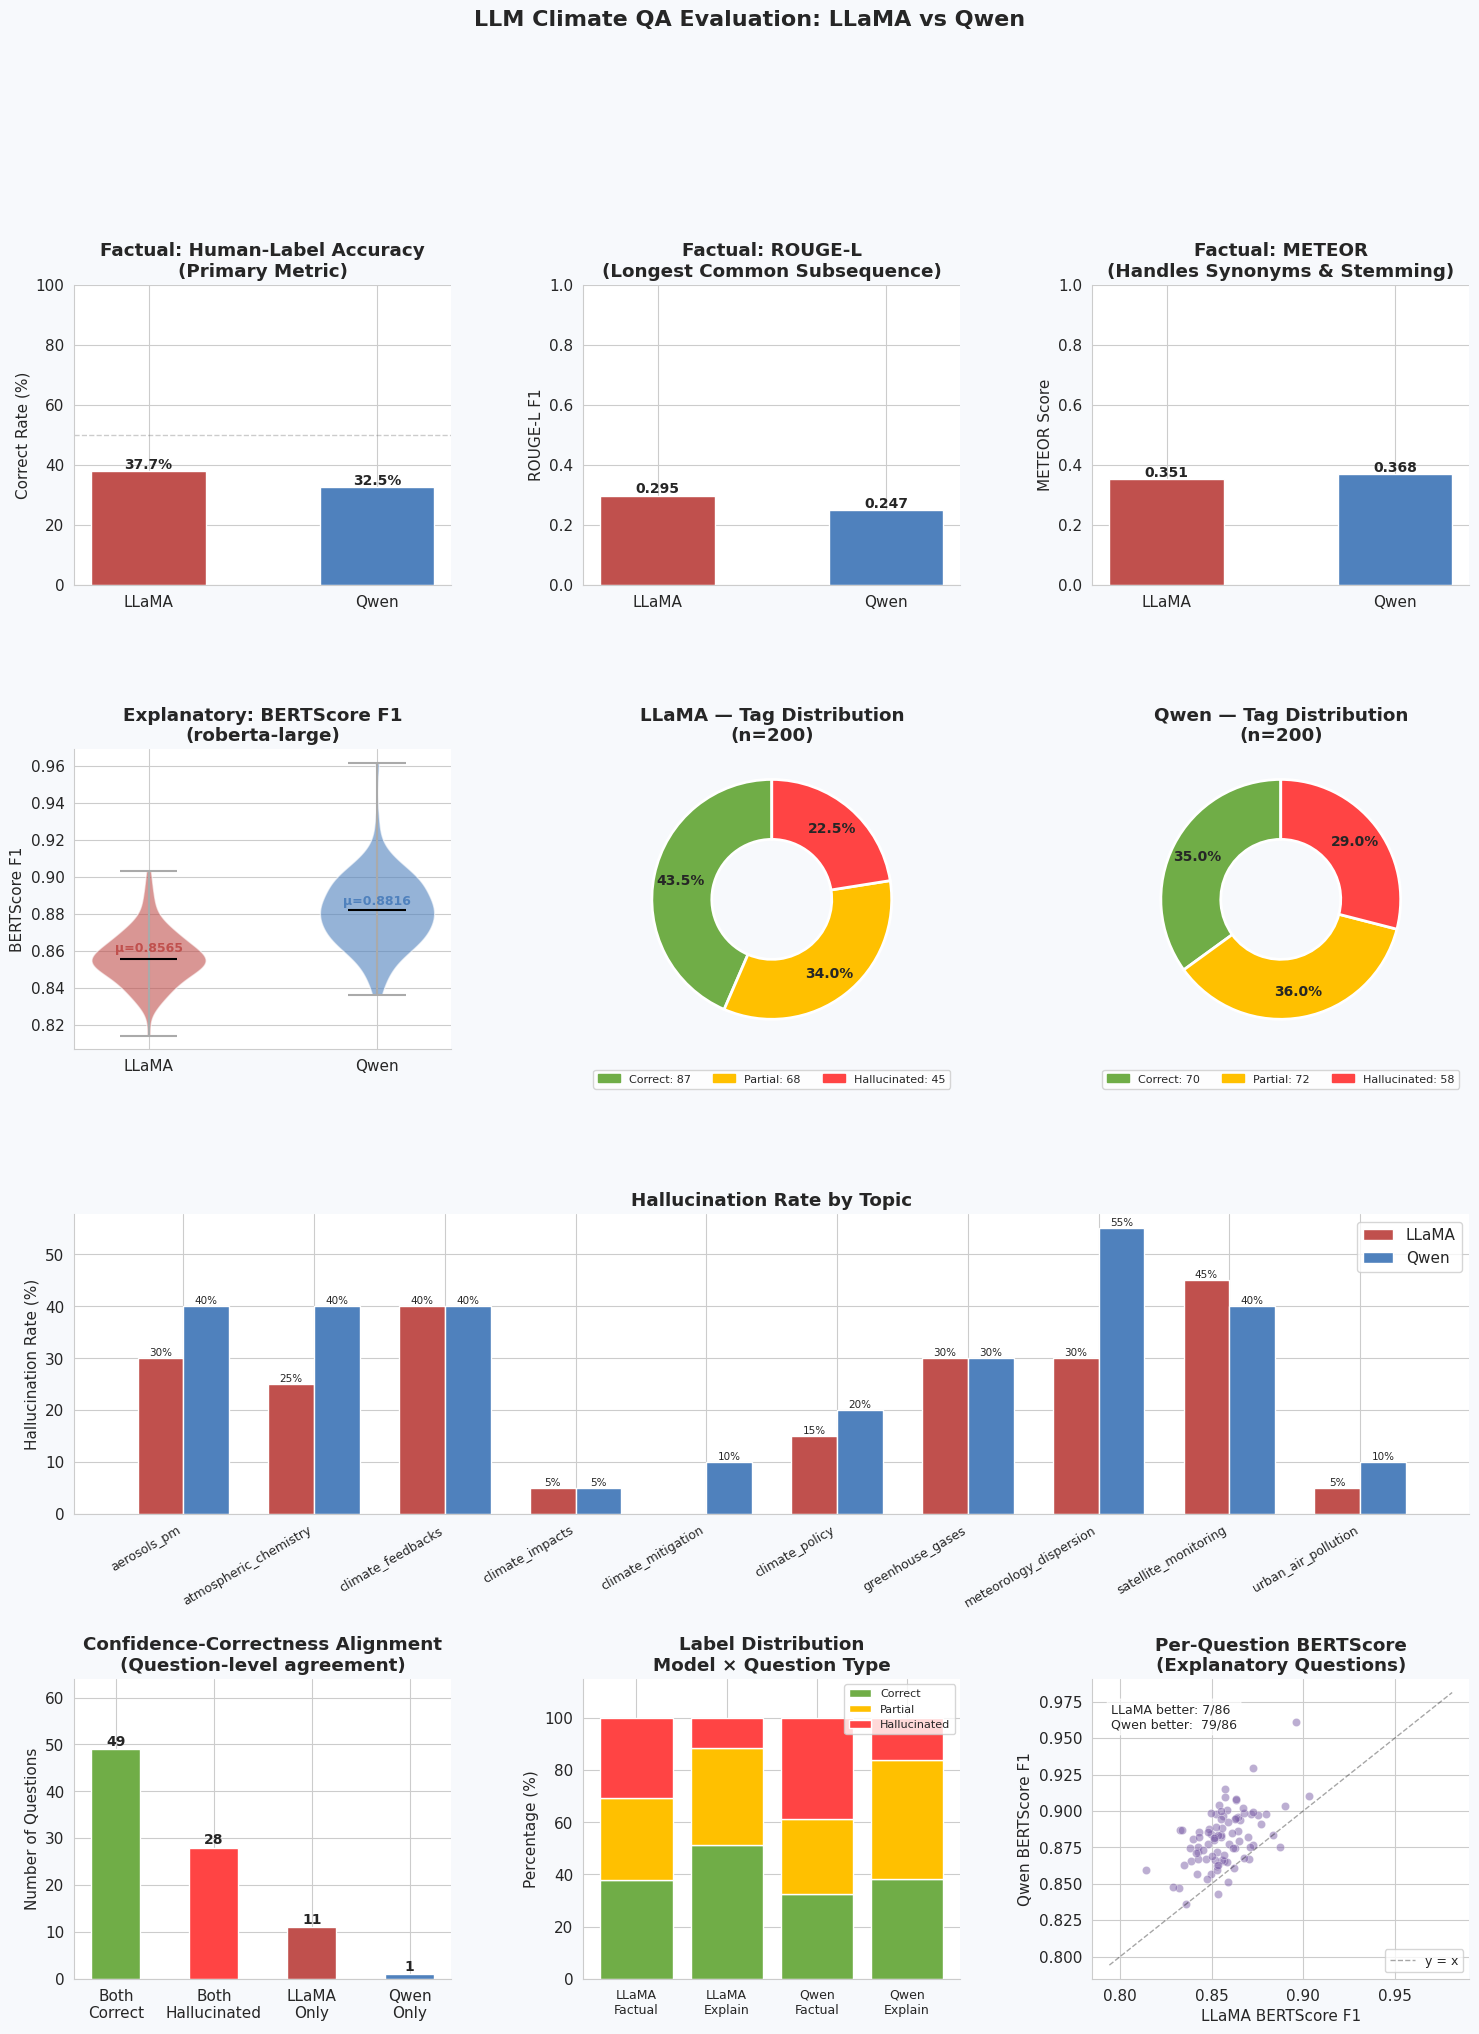

Plot saved to /content/climate_qa_evaluation.png


In [41]:
# ============================================================
# CELL 9 — All visualisations
# 4 rows × 3 columns = 10 plots:
#   Row 1 : Human accuracy | ROUGE-L       | METEOR
#   Row 2 : BERTScore      | LLaMA donut   | Qwen donut
#   Row 3 : Hallucination by topic (full width)
#   Row 4 : Alignment bar  | Stacked dist  | BERTScore scatter
# ============================================================
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 22))
fig.suptitle("LLM Climate QA Evaluation: LLaMA vs Qwen",
             fontsize=16, fontweight="bold", y=1.005)
fig.patch.set_facecolor("#F7F9FC")

gs = GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.35)

def bar_labels(ax, bars, fmt=".1f", suffix=""):
    ylim = ax.get_ylim()[1]
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + ylim * 0.01,
                f"{h:{fmt}}{suffix}", ha="center", fontsize=10, fontweight="bold")

# ── R1C1: Human-label factual accuracy ───────────────────────
ax = fig.add_subplot(gs[0, 0])
vals = [llama_factual_acc * 100, qwen_factual_acc * 100]
bars = ax.bar(["LLaMA", "Qwen"], vals,
              color=[COLORS["LLaMA"], COLORS["Qwen"]], edgecolor="white", width=0.5)
ax.set_ylim(0, 100)
bar_labels(ax, bars, suffix="%")
ax.axhline(50, color="gray", ls="--", alpha=0.4, lw=1)
ax.set_title("Factual: Human-Label Accuracy\n(Primary Metric)", fontweight="bold")
ax.set_ylabel("Correct Rate (%)")
ax.spines[["top", "right"]].set_visible(False)

# ── R1C2: ROUGE-L ─────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
vals = [factual["llama_rougeL"].mean(), factual["qwen_rougeL"].mean()]
bars = ax.bar(["LLaMA", "Qwen"], vals,
              color=[COLORS["LLaMA"], COLORS["Qwen"]], edgecolor="white", width=0.5)
ax.set_ylim(0, 1)
bar_labels(ax, bars, fmt=".3f")
ax.set_title("Factual: ROUGE-L\n(Longest Common Subsequence)", fontweight="bold")
ax.set_ylabel("ROUGE-L F1")
ax.spines[["top", "right"]].set_visible(False)

# ── R1C3: METEOR ──────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
vals = [factual["llama_meteor"].mean(), factual["qwen_meteor"].mean()]
bars = ax.bar(["LLaMA", "Qwen"], vals,
              color=[COLORS["LLaMA"], COLORS["Qwen"]], edgecolor="white", width=0.5)
ax.set_ylim(0, 1)
bar_labels(ax, bars, fmt=".3f")
ax.set_title("Factual: METEOR\n(Handles Synonyms & Stemming)", fontweight="bold")
ax.set_ylabel("METEOR Score")
ax.spines[["top", "right"]].set_visible(False)

# ── R2C1: BERTScore violin ────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
vp = ax.violinplot(
    [expl["llama_bertscore"].values, expl["qwen_bertscore"].values],
    positions=[1, 2], showmedians=True)
for body, color in zip(vp["bodies"], [COLORS["LLaMA"], COLORS["Qwen"]]):
    body.set_facecolor(color)
    body.set_alpha(0.6)
vp["cmedians"].set_color("black")
for part in ("cmins", "cmaxes", "cbars"):
    vp[part].set_color("#aaa")
ax.set_xticks([1, 2])
ax.set_xticklabels(["LLaMA", "Qwen"])
for i, (val, col) in enumerate(zip(
        [expl["llama_bertscore"].mean(), expl["qwen_bertscore"].mean()],
        [COLORS["LLaMA"], COLORS["Qwen"]]), 1):
    ax.text(i, val + 0.003, f"μ={val:.4f}", ha="center",
            fontsize=9, fontweight="bold", color=col)
ax.set_title("Explanatory: BERTScore F1\n(roberta-large)", fontweight="bold")
ax.set_ylabel("BERTScore F1")
ax.spines[["top", "right"]].set_visible(False)

# ── R2C2 & R2C3: Hallucination donut charts ──────────────────
for idx, (model, col) in enumerate([("LLaMA", "llama_tag"), ("Qwen", "qwen_tag")]):
    ax = fig.add_subplot(gs[1, idx + 1])
    counts = df[col].value_counts()
    labels = ["correct", "partial", "hallucinated"]
    sizes  = [counts.get(l, 0) for l in labels]
    colors = [COLORS[l] for l in labels]
    _, _, autotexts = ax.pie(
        sizes, colors=colors, autopct="%1.1f%%",
        startangle=90, pctdistance=0.78,
        wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2))
    for at in autotexts:
        at.set_fontsize(10)
        at.set_fontweight("bold")
    ax.set_title(f"{model} — Tag Distribution\n(n={len(df)})", fontweight="bold")
    ax.legend(
        handles=[mpatches.Patch(color=COLORS[l],
                 label=f"{l.title()}: {counts.get(l, 0)}") for l in labels],
        loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8)

# ── R3: Hallucination by topic (full width) ──────────────────
ax_topic = fig.add_subplot(gs[2, :])
topics = topic_hallu["topic"].tolist()
x = np.arange(len(topics))
w = 0.35
b1 = ax_topic.bar(x - w / 2, topic_hallu["LLaMA_Hallu_%"], w,
                   label="LLaMA", color=COLORS["LLaMA"], edgecolor="white")
b2 = ax_topic.bar(x + w / 2, topic_hallu["Qwen_Hallu_%"],  w,
                   label="Qwen",  color=COLORS["Qwen"],  edgecolor="white")
ax_topic.set_xticks(x)
ax_topic.set_xticklabels(topics, rotation=30, ha="right", fontsize=9)
ax_topic.set_ylabel("Hallucination Rate (%)")
ax_topic.set_title("Hallucination Rate by Topic", fontweight="bold")
ax_topic.legend()
ax_topic.spines[["top", "right"]].set_visible(False)
for b in list(b1) + list(b2):
    h = b.get_height()
    if h > 0:
        ax_topic.text(b.get_x() + b.get_width() / 2, h + 0.5,
                      f"{h:.0f}%", ha="center", fontsize=7.5)

# ── R4C1: Confidence-correctness alignment ────────────────────
ax = fig.add_subplot(gs[3, 0])
categories   = ["Both\nCorrect", "Both\nHallucinated", "LLaMA\nOnly", "Qwen\nOnly"]
counts_align = [len(both_correct), len(both_hallu), len(llama_better), len(qwen_better)]
bar_colors   = [COLORS["correct"], COLORS["hallucinated"], COLORS["LLaMA"], COLORS["Qwen"]]
bars = ax.bar(categories, counts_align, color=bar_colors, edgecolor="white", width=0.5)
ax.set_ylim(0, max(counts_align) + 15)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.8,
            str(int(b.get_height())), ha="center", fontsize=10, fontweight="bold")
ax.set_title("Confidence-Correctness Alignment\n(Question-level agreement)", fontweight="bold")
ax.set_ylabel("Number of Questions")
ax.spines[["top", "right"]].set_visible(False)

# ── R4C2: Stacked label distribution model × type ────────────
ax = fig.add_subplot(gs[3, 1])
combos   = ["LLaMA\nFactual", "LLaMA\nExplain", "Qwen\nFactual", "Qwen\nExplain"]
data_map = {}
for model, col in [("LLaMA", "llama_tag"), ("Qwen", "qwen_tag")]:
    for qtype in ["factual", "explanatory"]:
        sub = df[df["question_type"] == qtype][col].value_counts()
        n   = len(df[df["question_type"] == qtype])
        key = f"{model}\n{'Factual' if qtype == 'factual' else 'Explain'}"
        data_map[key] = {l: sub.get(l, 0) / n * 100
                         for l in ["correct", "partial", "hallucinated"]}
x   = np.arange(4)
bot = np.zeros(4)
for label in ["correct", "partial", "hallucinated"]:
    vals = [data_map[k][label] for k in combos]
    ax.bar(x, vals, bottom=bot, color=COLORS[label],
           label=label.title(), edgecolor="white")
    bot += np.array(vals)
ax.set_xticks(x)
ax.set_xticklabels(combos, fontsize=9)
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 115)
ax.set_title("Label Distribution\nModel × Question Type", fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# ── R4C3: BERTScore scatter per question ─────────────────────
ax = fig.add_subplot(gs[3, 2])
ax.scatter(expl["llama_bertscore"], expl["qwen_bertscore"],
           alpha=0.5, s=35, color="#7B5EA7", edgecolors="white", linewidths=0.4)
lo = min(expl["llama_bertscore"].min(), expl["qwen_bertscore"].min()) - 0.02
hi = max(expl["llama_bertscore"].max(), expl["qwen_bertscore"].max()) + 0.02
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.35, lw=1, label="y = x")
lb = (expl["llama_bertscore"] > expl["qwen_bertscore"]).sum()
qb = (expl["qwen_bertscore"]  > expl["llama_bertscore"]).sum()
ax.text(0.05, 0.92,
        f"LLaMA better: {lb}/{len(expl)}\nQwen better:  {qb}/{len(expl)}",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
ax.set_xlabel("LLaMA BERTScore F1")
ax.set_ylabel("Qwen BERTScore F1")
ax.set_title("Per-Question BERTScore\n(Explanatory Questions)", fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.savefig("/content/climate_qa_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to /content/climate_qa_evaluation.png")

# **L vs IL**

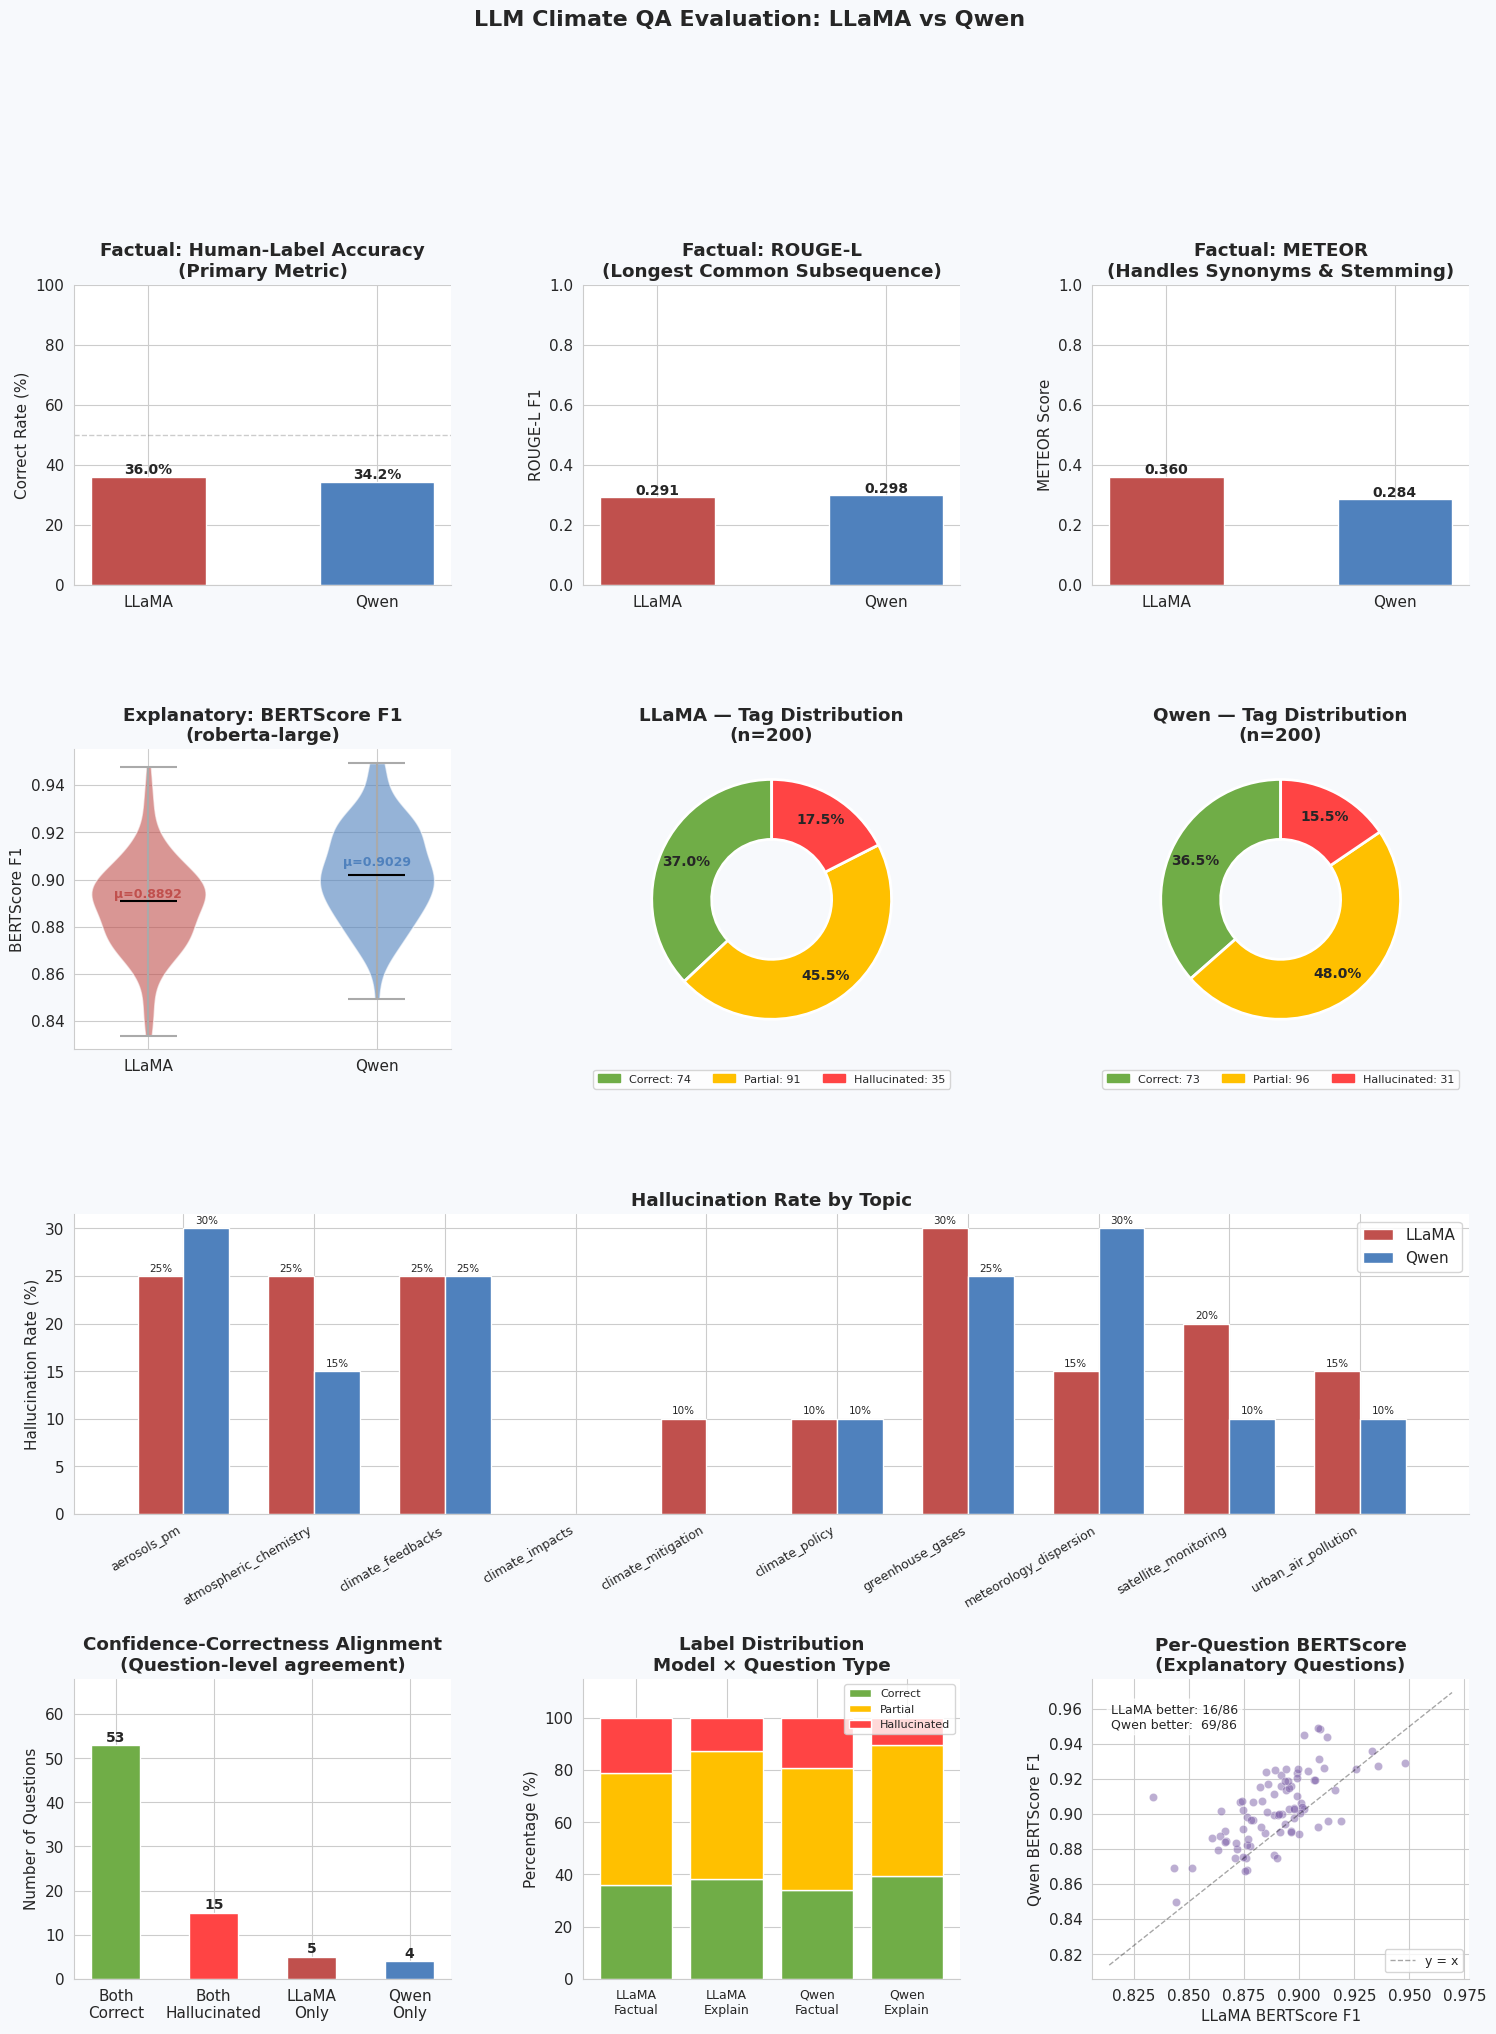

Plot saved to /content/climate_qa_evaluation.png


In [48]:
# ============================================================
# CELL 9 — All visualisations
# 4 rows × 3 columns = 10 plots:
#   Row 1 : Human accuracy | ROUGE-L       | METEOR
#   Row 2 : BERTScore      | LLaMA donut   | Qwen donut
#   Row 3 : Hallucination by topic (full width)
#   Row 4 : Alignment bar  | Stacked dist  | BERTScore scatter
# ============================================================
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 22))
fig.suptitle("LLM Climate QA Evaluation: LLaMA vs Qwen",
             fontsize=16, fontweight="bold", y=1.005)
fig.patch.set_facecolor("#F7F9FC")

gs = GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.35)

def bar_labels(ax, bars, fmt=".1f", suffix=""):
    ylim = ax.get_ylim()[1]
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + ylim * 0.01,
                f"{h:{fmt}}{suffix}", ha="center", fontsize=10, fontweight="bold")

# ── R1C1: Human-label factual accuracy ───────────────────────
ax = fig.add_subplot(gs[0, 0])
vals = [llama_factual_acc * 100, qwen_factual_acc * 100]
bars = ax.bar(["LLaMA", "Qwen"], vals,
              color=[COLORS["LLaMA"], COLORS["Qwen"]], edgecolor="white", width=0.5)
ax.set_ylim(0, 100)
bar_labels(ax, bars, suffix="%")
ax.axhline(50, color="gray", ls="--", alpha=0.4, lw=1)
ax.set_title("Factual: Human-Label Accuracy\n(Primary Metric)", fontweight="bold")
ax.set_ylabel("Correct Rate (%)")
ax.spines[["top", "right"]].set_visible(False)

# ── R1C2: ROUGE-L ─────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
vals = [factual["llama_rougeL"].mean(), factual["qwen_rougeL"].mean()]
bars = ax.bar(["LLaMA", "Qwen"], vals,
              color=[COLORS["LLaMA"], COLORS["Qwen"]], edgecolor="white", width=0.5)
ax.set_ylim(0, 1)
bar_labels(ax, bars, fmt=".3f")
ax.set_title("Factual: ROUGE-L\n(Longest Common Subsequence)", fontweight="bold")
ax.set_ylabel("ROUGE-L F1")
ax.spines[["top", "right"]].set_visible(False)

# ── R1C3: METEOR ──────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
vals = [factual["llama_meteor"].mean(), factual["qwen_meteor"].mean()]
bars = ax.bar(["LLaMA", "Qwen"], vals,
              color=[COLORS["LLaMA"], COLORS["Qwen"]], edgecolor="white", width=0.5)
ax.set_ylim(0, 1)
bar_labels(ax, bars, fmt=".3f")
ax.set_title("Factual: METEOR\n(Handles Synonyms & Stemming)", fontweight="bold")
ax.set_ylabel("METEOR Score")
ax.spines[["top", "right"]].set_visible(False)

# ── R2C1: BERTScore violin ────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
vp = ax.violinplot(
    [expl["llama_bertscore"].values, expl["qwen_bertscore"].values],
    positions=[1, 2], showmedians=True)
for body, color in zip(vp["bodies"], [COLORS["LLaMA"], COLORS["Qwen"]]):
    body.set_facecolor(color)
    body.set_alpha(0.6)
vp["cmedians"].set_color("black")
for part in ("cmins", "cmaxes", "cbars"):
    vp[part].set_color("#aaa")
ax.set_xticks([1, 2])
ax.set_xticklabels(["LLaMA", "Qwen"])
for i, (val, col) in enumerate(zip(
        [expl["llama_bertscore"].mean(), expl["qwen_bertscore"].mean()],
        [COLORS["LLaMA"], COLORS["Qwen"]]), 1):
    ax.text(i, val + 0.003, f"μ={val:.4f}", ha="center",
            fontsize=9, fontweight="bold", color=col)
ax.set_title("Explanatory: BERTScore F1\n(roberta-large)", fontweight="bold")
ax.set_ylabel("BERTScore F1")
ax.spines[["top", "right"]].set_visible(False)

# ── R2C2 & R2C3: Hallucination donut charts ──────────────────
for idx, (model, col) in enumerate([("LLaMA", "llama_tag"), ("Qwen", "qwen_tag")]):
    ax = fig.add_subplot(gs[1, idx + 1])
    counts = df[col].value_counts()
    labels = ["correct", "partial", "hallucinated"]
    sizes  = [counts.get(l, 0) for l in labels]
    colors = [COLORS[l] for l in labels]
    _, _, autotexts = ax.pie(
        sizes, colors=colors, autopct="%1.1f%%",
        startangle=90, pctdistance=0.78,
        wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2))
    for at in autotexts:
        at.set_fontsize(10)
        at.set_fontweight("bold")
    ax.set_title(f"{model} — Tag Distribution\n(n={len(df)})", fontweight="bold")
    ax.legend(
        handles=[mpatches.Patch(color=COLORS[l],
                 label=f"{l.title()}: {counts.get(l, 0)}") for l in labels],
        loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8)

# ── R3: Hallucination by topic (full width) ──────────────────
ax_topic = fig.add_subplot(gs[2, :])
topics = topic_hallu["topic"].tolist()
x = np.arange(len(topics))
w = 0.35
b1 = ax_topic.bar(x - w / 2, topic_hallu["LLaMA_Hallu_%"], w,
                   label="LLaMA", color=COLORS["LLaMA"], edgecolor="white")
b2 = ax_topic.bar(x + w / 2, topic_hallu["Qwen_Hallu_%"],  w,
                   label="Qwen",  color=COLORS["Qwen"],  edgecolor="white")
ax_topic.set_xticks(x)
ax_topic.set_xticklabels(topics, rotation=30, ha="right", fontsize=9)
ax_topic.set_ylabel("Hallucination Rate (%)")
ax_topic.set_title("Hallucination Rate by Topic", fontweight="bold")
ax_topic.legend()
ax_topic.spines[["top", "right"]].set_visible(False)
for b in list(b1) + list(b2):
    h = b.get_height()
    if h > 0:
        ax_topic.text(b.get_x() + b.get_width() / 2, h + 0.5,
                      f"{h:.0f}%", ha="center", fontsize=7.5)

# ── R4C1: Confidence-correctness alignment ────────────────────
ax = fig.add_subplot(gs[3, 0])
categories   = ["Both\nCorrect", "Both\nHallucinated", "LLaMA\nOnly", "Qwen\nOnly"]
counts_align = [len(both_correct), len(both_hallu), len(llama_better), len(qwen_better)]
bar_colors   = [COLORS["correct"], COLORS["hallucinated"], COLORS["LLaMA"], COLORS["Qwen"]]
bars = ax.bar(categories, counts_align, color=bar_colors, edgecolor="white", width=0.5)
ax.set_ylim(0, max(counts_align) + 15)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.8,
            str(int(b.get_height())), ha="center", fontsize=10, fontweight="bold")
ax.set_title("Confidence-Correctness Alignment\n(Question-level agreement)", fontweight="bold")
ax.set_ylabel("Number of Questions")
ax.spines[["top", "right"]].set_visible(False)

# ── R4C2: Stacked label distribution model × type ────────────
ax = fig.add_subplot(gs[3, 1])
combos   = ["LLaMA\nFactual", "LLaMA\nExplain", "Qwen\nFactual", "Qwen\nExplain"]
data_map = {}
for model, col in [("LLaMA", "llama_tag"), ("Qwen", "qwen_tag")]:
    for qtype in ["factual", "explanatory"]:
        sub = df[df["question_type"] == qtype][col].value_counts()
        n   = len(df[df["question_type"] == qtype])
        key = f"{model}\n{'Factual' if qtype == 'factual' else 'Explain'}"
        data_map[key] = {l: sub.get(l, 0) / n * 100
                         for l in ["correct", "partial", "hallucinated"]}
x   = np.arange(4)
bot = np.zeros(4)
for label in ["correct", "partial", "hallucinated"]:
    vals = [data_map[k][label] for k in combos]
    ax.bar(x, vals, bottom=bot, color=COLORS[label],
           label=label.title(), edgecolor="white")
    bot += np.array(vals)
ax.set_xticks(x)
ax.set_xticklabels(combos, fontsize=9)
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 115)
ax.set_title("Label Distribution\nModel × Question Type", fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# ── R4C3: BERTScore scatter per question ─────────────────────
ax = fig.add_subplot(gs[3, 2])
ax.scatter(expl["llama_bertscore"], expl["qwen_bertscore"],
           alpha=0.5, s=35, color="#7B5EA7", edgecolors="white", linewidths=0.4)
lo = min(expl["llama_bertscore"].min(), expl["qwen_bertscore"].min()) - 0.02
hi = max(expl["llama_bertscore"].max(), expl["qwen_bertscore"].max()) + 0.02
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.35, lw=1, label="y = x")
lb = (expl["llama_bertscore"] > expl["qwen_bertscore"]).sum()
qb = (expl["qwen_bertscore"]  > expl["llama_bertscore"]).sum()
ax.text(0.05, 0.92,
        f"LLaMA better: {lb}/{len(expl)}\nQwen better:  {qb}/{len(expl)}",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
ax.set_xlabel("LLaMA BERTScore F1")
ax.set_ylabel("Qwen BERTScore F1")
ax.set_title("Per-Question BERTScore\n(Explanatory Questions)", fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.savefig("/content/climate_qa_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to /content/climate_qa_evaluation.png")

# **Export**

In [ ]:
# # ============================================================
# # CELL 10 — Save all results to CSV
# # ============================================================
# df = df.merge(expl[["id", "llama_bertscore", "qwen_bertscore"]],
#               on="id", how="left")
# df = df.merge(factual[["id", "llama_rougeL", "qwen_rougeL",
#                         "llama_meteor", "qwen_meteor"]],
#               on="id", how="left")

# df.to_csv("/content/evaluation_results.csv",      index=False)
# expl.to_csv("/content/bertscore_results.csv",     index=False)
# hallu_overall.to_csv("/content/hallucination_summary.csv", index=False)
# topic_hallu.to_csv("/content/topic_hallucination.csv",     index=False)

# print("Saved:")
# print("  /content/evaluation_results.csv       — full results with all scores")
# print("  /content/bertscore_results.csv         — explanatory questions + BERTScores")
# print("  /content/hallucination_summary.csv     — overall hallucination stats")
# print("  /content/topic_hallucination.csv       — hallucination rates per topic")
